## Credit Card Fraud Detection

In this project you will predict fraudulent credit card transactions with the help of Machine learning models. Please import the following libraries to get started.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

from sklearn import metrics
from sklearn import preprocessing

## Exploratory data analysis

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
#observe the different feature type present in the data

print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nDataset info:")
print(df.info())
print("\nBasic statistics:")
print(df.describe())

Dataset shape: (284807, 31)

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  flo

Here we will observe the distribution of our classes

In [4]:
classes=df['Class'].value_counts()
normal_share=classes[0]/df['Class'].count()*100
fraud_share=classes[1]/df['Class'].count()*100

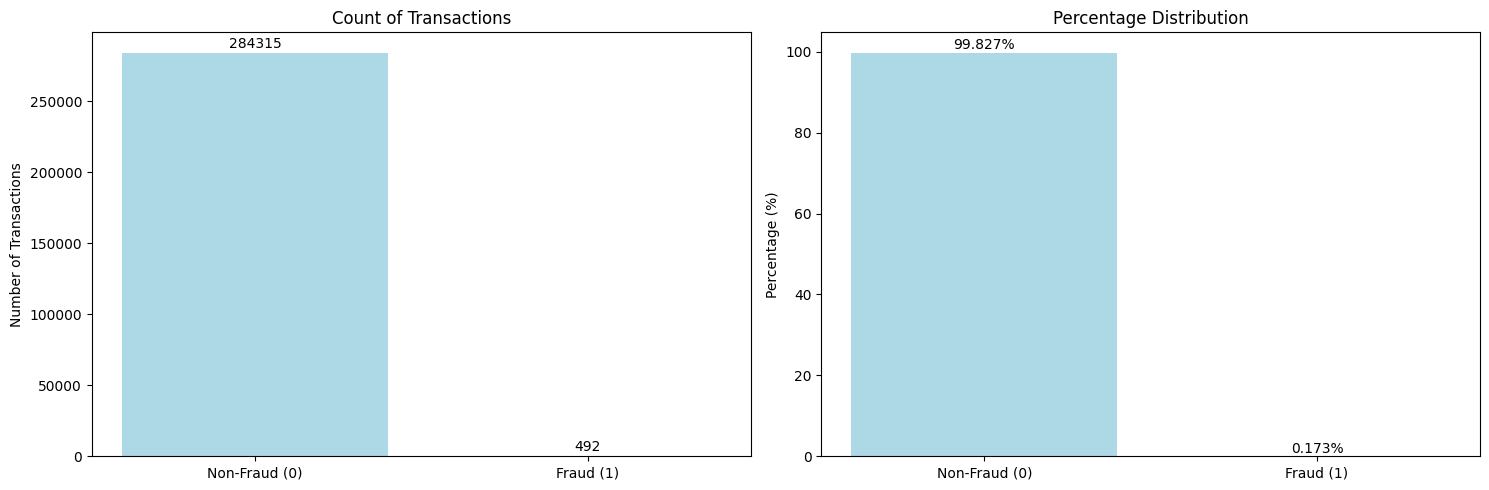

Total transactions: 284807
Non-fraudulent: 284315 (99.827%)
Fraudulent: 492 (0.173%)
Imbalance ratio: 577.9:1


In [5]:
# Create a bar plot for the number and percentage of fraudulent vs non-fraudulent transcations

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Count of transactions
ax1.bar(['Non-Fraud (0)', 'Fraud (1)'], [classes[0], classes[1]], 
        color=['lightblue', 'salmon'])
ax1.set_title('Count of Transactions')
ax1.set_ylabel('Number of Transactions')
for i, v in enumerate([classes[0], classes[1]]):
    ax1.text(i, v + 1000, str(v), ha='center', va='bottom')

# Plot 2: Percentage distribution
ax2.bar(['Non-Fraud (0)', 'Fraud (1)'], [normal_share, fraud_share], 
        color=['lightblue', 'salmon'])
ax2.set_title('Percentage Distribution')
ax2.set_ylabel('Percentage (%)')
for i, v in enumerate([normal_share, fraud_share]):
    ax2.text(i, v + 0.01, f'{v:.3f}%', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print(f"Total transactions: {len(df)}")
print(f"Non-fraudulent: {classes[0]} ({normal_share:.3f}%)")
print(f"Fraudulent: {classes[1]} ({fraud_share:.3f}%)")
print(f"Imbalance ratio: {classes[0]/classes[1]:.1f}:1")

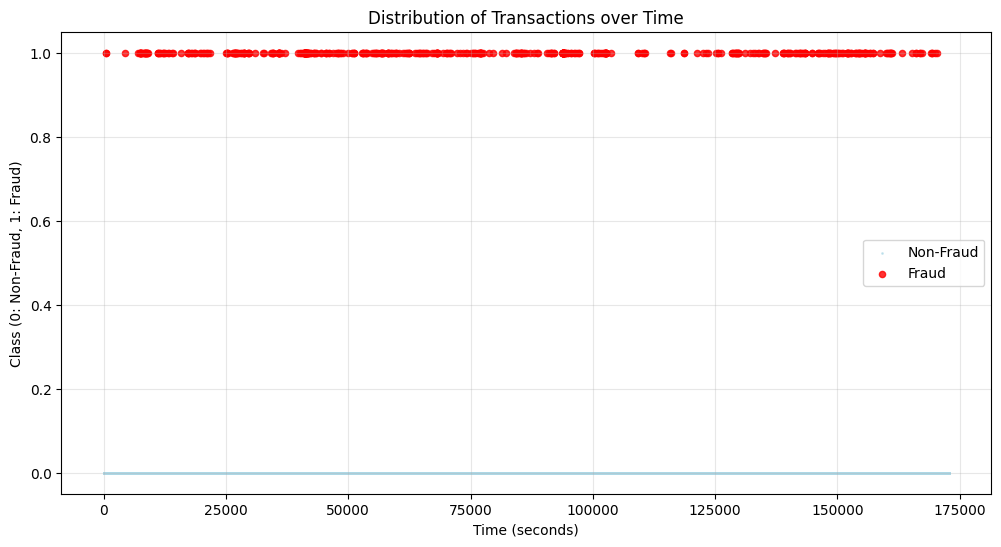

Time range: 0 to 172792 seconds
Duration: 48.0 hours


In [6]:
# Create a scatter plot to observe the distribution of classes with time
plt.figure(figsize=(12, 6))

# Separate fraud and non-fraud transactions
fraud_data = df[df['Class'] == 1]
normal_data = df[df['Class'] == 0]

# Create scatter plot
plt.scatter(normal_data['Time'], normal_data['Class'], alpha=0.6, s=1, label='Non-Fraud', color='lightblue')
plt.scatter(fraud_data['Time'], fraud_data['Class'], alpha=0.8, s=20, label='Fraud', color='red')

plt.title('Distribution of Transactions over Time')
plt.xlabel('Time (seconds)')
plt.ylabel('Class (0: Non-Fraud, 1: Fraud)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Time range: {df['Time'].min():.0f} to {df['Time'].max():.0f} seconds")
print(f"Duration: {(df['Time'].max() - df['Time'].min())/3600:.1f} hours")

<Figure size 1400x800 with 0 Axes>

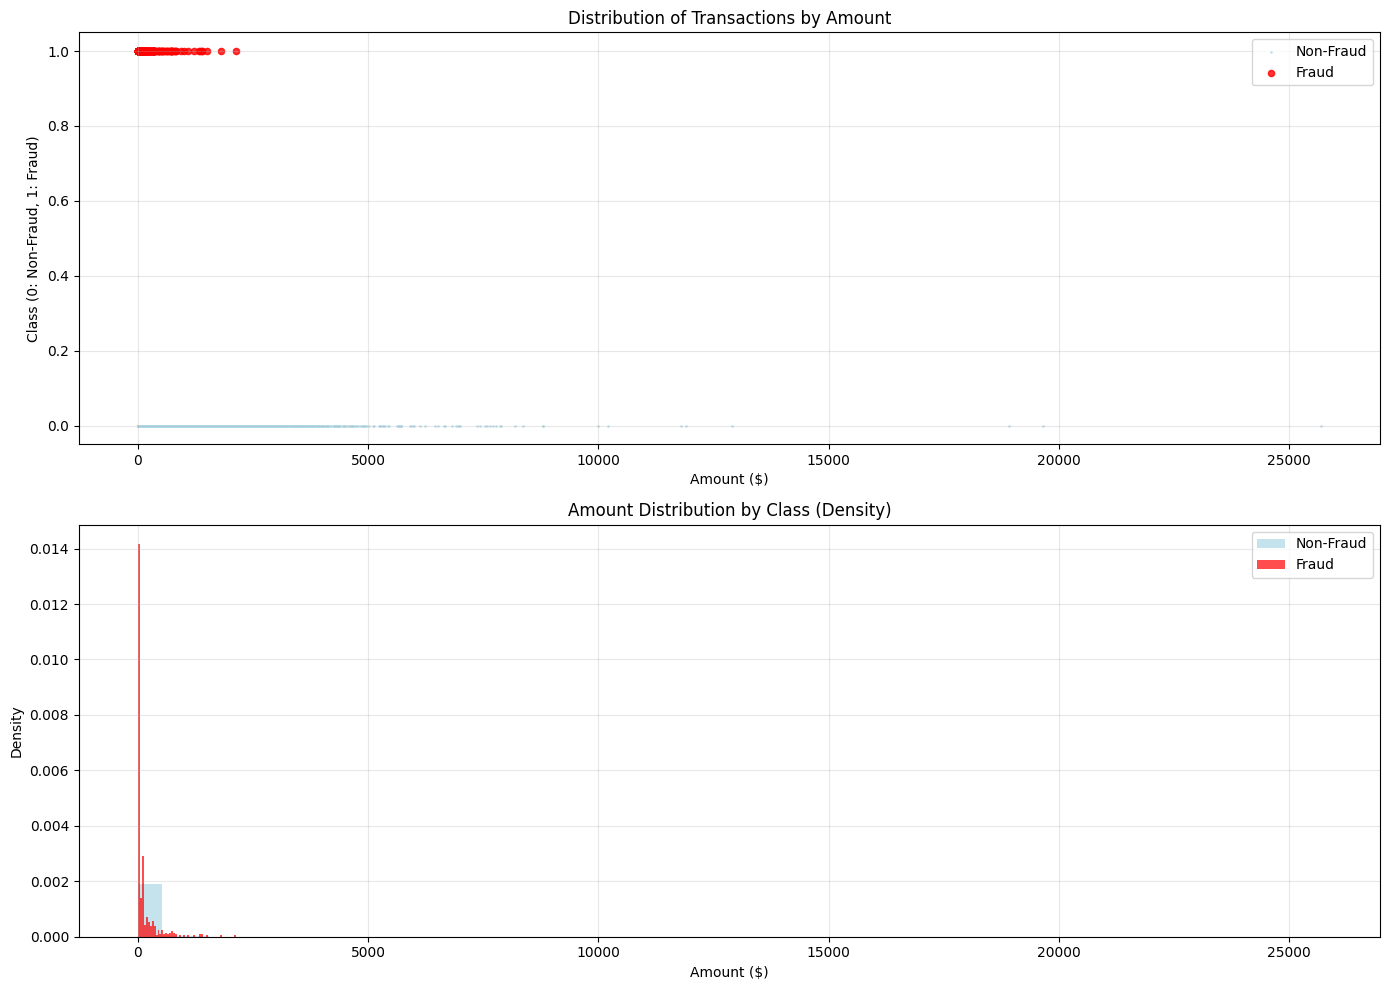

Amount Statistics:
Overall - Min: $0.00, Max: $25691.16, Mean: $88.35
Non-Fraud - Min: $0.00, Max: $25691.16, Mean: $88.29
Fraud - Min: $0.00, Max: $2125.87, Mean: $122.21

High-value transactions (>$1000): 2940 total, 9 fraudulent


In [7]:
# Create a scatter plot to observe the distribution of classes with Amount
plt.figure(figsize=(14, 8))

# Separate fraud and non-fraud transactions
fraud_data = df[df['Class'] == 1]
normal_data = df[df['Class'] == 0]

# Create subplots for better visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Scatter plot
ax1.scatter(normal_data['Amount'], normal_data['Class'], alpha=0.6, s=1, label='Non-Fraud', color='lightblue')
ax1.scatter(fraud_data['Amount'], fraud_data['Class'], alpha=0.8, s=20, label='Fraud', color='red')
ax1.set_title('Distribution of Transactions by Amount')
ax1.set_xlabel('Amount ($)')
ax1.set_ylabel('Class (0: Non-Fraud, 1: Fraud)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Histogram comparison
ax2.hist(normal_data['Amount'], bins=50, alpha=0.7, label='Non-Fraud', color='lightblue', density=True)
ax2.hist(fraud_data['Amount'], bins=50, alpha=0.7, label='Fraud', color='red', density=True)
ax2.set_title('Amount Distribution by Class (Density)')
ax2.set_xlabel('Amount ($)')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistical analysis
print("Amount Statistics:")
print(f"Overall - Min: ${df['Amount'].min():.2f}, Max: ${df['Amount'].max():.2f}, Mean: ${df['Amount'].mean():.2f}")
print(f"Non-Fraud - Min: ${normal_data['Amount'].min():.2f}, Max: ${normal_data['Amount'].max():.2f}, Mean: ${normal_data['Amount'].mean():.2f}")
print(f"Fraud - Min: ${fraud_data['Amount'].min():.2f}, Max: ${fraud_data['Amount'].max():.2f}, Mean: ${fraud_data['Amount'].mean():.2f}")

print(f"\nHigh-value transactions (>$1000): {len(df[df['Amount'] > 1000])} total, {len(fraud_data[fraud_data['Amount'] > 1000])} fraudulent")

In [8]:
# Drop unnecessary columns
# For this fraud detection task, we'll keep all features as they might be important
# The Time feature could contain temporal patterns, but for simplicity we'll drop it
# All V1-V28 features are PCA components and should be kept
# Amount and Class are essential

print("Original features:", df.columns.tolist())
print("Original shape:", df.shape)

# Drop the Time column as it's not directly predictive of fraud patterns
df_model = df.drop('Time', axis=1)

print("\nAfter dropping Time column:")
print("Features:", df_model.columns.tolist())
print("New shape:", df_model.shape)

# Let's also check for any missing values before modeling
print(f"\nMissing values check:")
print(df_model.isnull().sum().sum(), "total missing values")

Original features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
Original shape: (284807, 31)

After dropping Time column:
Features: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']
New shape: (284807, 30)

Missing values check:
0 total missing values


### Splitting the data into train & test data

In [9]:
y = df_model['Class']  # class variable
X = df_model.drop('Class', axis=1)  # feature variables

print("Target variable (y) shape:", y.shape)
print("Feature matrix (X) shape:", X.shape)
print(f"Features in X: {list(X.columns)}")

Target variable (y) shape: (284807,)
Feature matrix (X) shape: (284807, 29)
Features in X: ['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [10]:
from sklearn import model_selection

# Use stratified split to maintain class distribution in both train and test sets
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # Important: maintains class balance
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Test target shape:", y_test.shape)

Training set shape: (227845, 29)
Test set shape: (56962, 29)
Training target shape: (227845,)
Test target shape: (56962,)


##### Preserve X_test & y_test to evaluate on the test data once you build the model

In [11]:
print("Class distribution check:")
print(f"Total fraudulent cases: {np.sum(y)}")
print(f"Training fraudulent cases: {np.sum(y_train)}")
print(f"Test fraudulent cases: {np.sum(y_test)}")

print(f"\nTraining set fraud rate: {np.sum(y_train)/len(y_train)*100:.3f}%")
print(f"Test set fraud rate: {np.sum(y_test)/len(y_test)*100:.3f}%")
print(f"Original fraud rate: {np.sum(y)/len(y)*100:.3f}%")

# Verify the split maintains the imbalance
print(f"\nClass distribution in training:")
print(y_train.value_counts().sort_index())
print(f"\nClass distribution in test:")
print(y_test.value_counts().sort_index())

Class distribution check:
Total fraudulent cases: 492
Training fraudulent cases: 394
Test fraudulent cases: 98

Training set fraud rate: 0.173%
Test set fraud rate: 0.172%
Original fraud rate: 0.173%

Class distribution in training:
Class
0    227451
1       394
Name: count, dtype: int64

Class distribution in test:
Class
0    56864
1       98
Name: count, dtype: int64


### Plotting the distribution of a variable

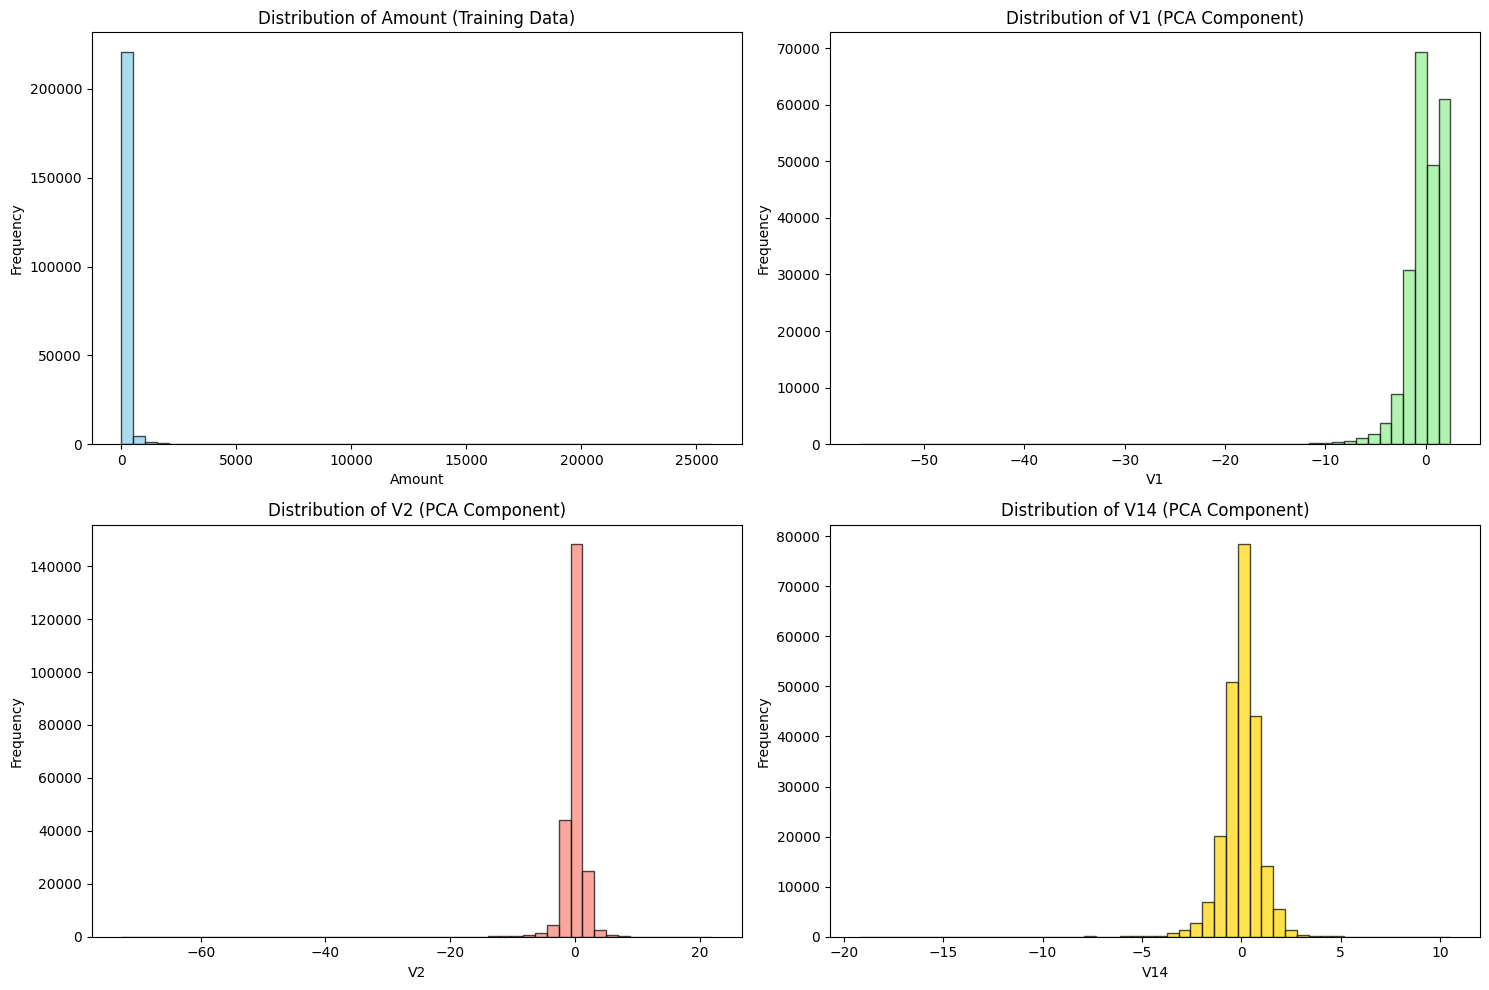

Skewness Analysis:
Amount skewness: 18.194
V1 skewness: -3.306
V2 skewness: -4.779
V14 skewness: -1.969

Note: Skewness > 1 or < -1 indicates high skewness


In [12]:
# plot the histogram of a variable from the dataset to see the skewness
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot Amount distribution (most likely to be skewed)
axes[0, 0].hist(X_train['Amount'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Amount (Training Data)')
axes[0, 0].set_xlabel('Amount')
axes[0, 0].set_ylabel('Frequency')

# Plot a few V columns to check PCA component distributions
axes[0, 1].hist(X_train['V1'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of V1 (PCA Component)')
axes[0, 1].set_xlabel('V1')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(X_train['V2'], bins=50, alpha=0.7, color='salmon', edgecolor='black')
axes[1, 0].set_title('Distribution of V2 (PCA Component)')
axes[1, 0].set_xlabel('V2')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(X_train['V14'], bins=50, alpha=0.7, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribution of V14 (PCA Component)')
axes[1, 1].set_xlabel('V14')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check skewness statistics
from scipy import stats
print("Skewness Analysis:")
print(f"Amount skewness: {stats.skew(X_train['Amount']):.3f}")
print(f"V1 skewness: {stats.skew(X_train['V1']):.3f}")
print(f"V2 skewness: {stats.skew(X_train['V2']):.3f}")
print(f"V14 skewness: {stats.skew(X_train['V14']):.3f}")
print("\nNote: Skewness > 1 or < -1 indicates high skewness")

### If there is skewness present in the distribution use:
- <b>Power Transformer</b> package present in the <b>preprocessing library provided by sklearn</b> to make distribution more gaussian

In [13]:
# Apply: preprocessing.PowerTransformer(copy=False) to fit & transform the train & test data

# Initialize PowerTransformer
pt = preprocessing.PowerTransformer(copy=False)

# Fit and transform training data
print("Original X_train shape:", X_train.shape)
X_train_transformed = pt.fit_transform(X_train)
print("Transformed X_train shape:", X_train_transformed.shape)

# Transform test data using the same transformer (fitted on training data)
X_test_transformed = pt.transform(X_test)
print("Transformed X_test shape:", X_test_transformed.shape)

# Convert back to DataFrame for easier handling
X_train_transformed = pd.DataFrame(X_train_transformed, columns=X_train.columns)
X_test_transformed = pd.DataFrame(X_test_transformed, columns=X_test.columns)

print("\nPowerTransformer applied successfully!")
print("Features have been made more Gaussian-like.")

Original X_train shape: (227845, 29)
Transformed X_train shape: (227845, 29)
Transformed X_test shape: (56962, 29)

PowerTransformer applied successfully!
Features have been made more Gaussian-like.


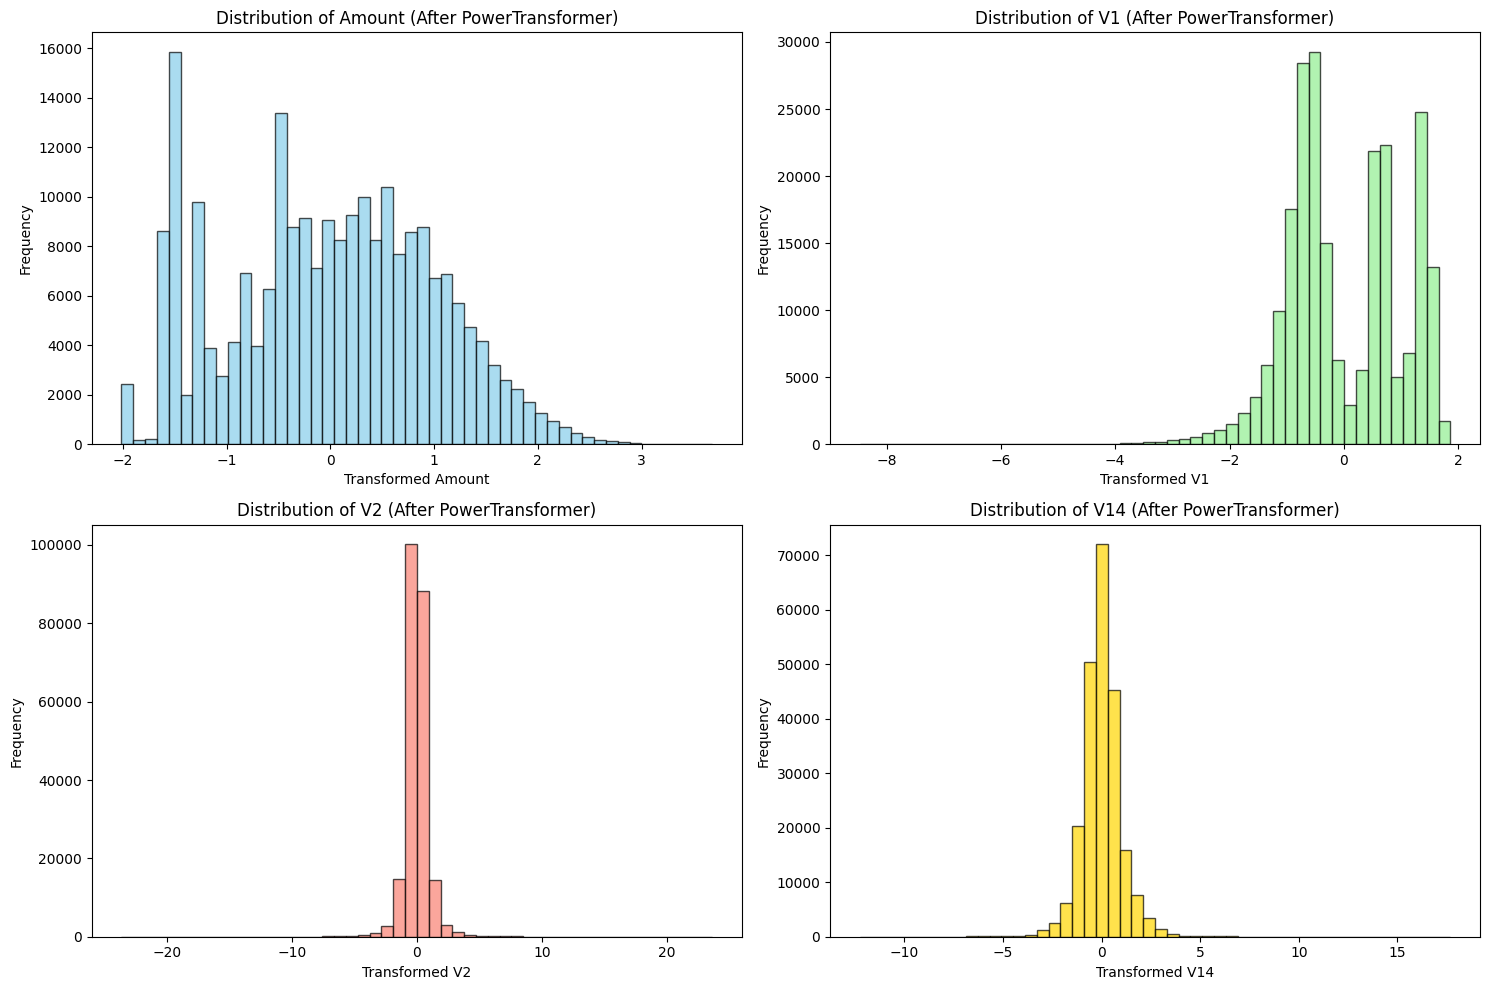

Skewness Analysis (After PowerTransformer):
Amount skewness: 0.018
V1 skewness: -0.218
V2 skewness: 0.337
V14 skewness: 0.101

Improvement Summary:
- Distributions should now be more Gaussian-like
- Skewness values should be closer to 0
- Data is ready for machine learning models!


In [14]:
# plot the histogram of a variable from the dataset again to see the result 
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot the same variables after transformation
axes[0, 0].hist(X_train_transformed['Amount'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Distribution of Amount (After PowerTransformer)')
axes[0, 0].set_xlabel('Transformed Amount')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(X_train_transformed['V1'], bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_title('Distribution of V1 (After PowerTransformer)')
axes[0, 1].set_xlabel('Transformed V1')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(X_train_transformed['V2'], bins=50, alpha=0.7, color='salmon', edgecolor='black')
axes[1, 0].set_title('Distribution of V2 (After PowerTransformer)')
axes[1, 0].set_xlabel('Transformed V2')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(X_train_transformed['V14'], bins=50, alpha=0.7, color='gold', edgecolor='black')
axes[1, 1].set_title('Distribution of V14 (After PowerTransformer)')
axes[1, 1].set_xlabel('Transformed V14')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Check skewness after transformation
print("Skewness Analysis (After PowerTransformer):")
print(f"Amount skewness: {stats.skew(X_train_transformed['Amount']):.3f}")
print(f"V1 skewness: {stats.skew(X_train_transformed['V1']):.3f}")
print(f"V2 skewness: {stats.skew(X_train_transformed['V2']):.3f}")
print(f"V14 skewness: {stats.skew(X_train_transformed['V14']):.3f}")

print("\nImprovement Summary:")
print("- Distributions should now be more Gaussian-like")
print("- Skewness values should be closer to 0")
print("- Data is ready for machine learning models!")

## Model Building
- Build different models on the imbalanced dataset and see the result

In [15]:
# Logistic Regression
from sklearn import linear_model #import the package

# Hyperparameter values for regularization strength
num_C = [0.001, 0.01, 0.1, 1, 10, 100]  # --> list of values for C parameter
cv_num = 5   # --> number of cross-validation folds

print("Logistic Regression Setup:")
print(f"C values to test: {num_C}")
print(f"Cross-validation folds: {cv_num}")
print("\nNote: C is the inverse of regularization strength")
print("- Lower C = More regularization (simpler model)")
print("- Higher C = Less regularization (more complex model)")

Logistic Regression Setup:
C values to test: [0.001, 0.01, 0.1, 1, 10, 100]
Cross-validation folds: 5

Note: C is the inverse of regularization strength
- Lower C = More regularization (simpler model)
- Higher C = Less regularization (more complex model)


#### perfom cross validation on the X_train & y_train to create:
- X_train_cv
- X_test_cv 
- y_train_cv
- y_test_cv 

In [16]:
#perform cross validation
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Create the logistic regression model
log_reg = LogisticRegression(random_state=42, max_iter=1000)

# Set up parameter grid
param_grid = {'C': num_C}

print("Setting up GridSearchCV for Logistic Regression...")

#perform hyperparameter tuning
# Use AUC-ROC as scoring metric (good for imbalanced data)
grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    cv=cv_num,
    scoring='roc_auc',  # Best for imbalanced classification
    n_jobs=-1,  # Use all processors
    verbose=1
)

# Fit the grid search
print("Training models with different C values...")
grid_search.fit(X_train_transformed, y_train)

#print the evaluation result by choosing a evaluation metric
print("\n")
print("Logistic Regression Results:")

print(f"Best Cross-Validation AUC Score: {grid_search.best_score_:.4f}")

#print the optimum value of hyperparameters
print(f"Best hyperparameters: {grid_search.best_params_}")

# Show all results
print(f"\nAll CV Results:")
for i, (params, score) in enumerate(zip(grid_search.cv_results_['params'], 
                                        grid_search.cv_results_['mean_test_score'])):
    print(f"C={params['C']:6} -> AUC: {score:.4f}")

Setting up GridSearchCV for Logistic Regression...
Training models with different C values...
Fitting 5 folds for each of 6 candidates, totalling 30 fits


Logistic Regression Results:
Best Cross-Validation AUC Score: 0.9815
Best hyperparameters: {'C': 0.01}

All CV Results:
C= 0.001 -> AUC: 0.9788
C=  0.01 -> AUC: 0.9815
C=   0.1 -> AUC: 0.9811
C=     1 -> AUC: 0.9812
C=    10 -> AUC: 0.9812
C=   100 -> AUC: 0.9812


### Similarly explore other algorithms by building models like:
- KNN
- SVM
- Decision Tree
- Random Forest
- XGBoost

In [17]:
# KNN (K-Nearest Neighbors)
from sklearn.neighbors import KNeighborsClassifier

print("K-Nearest Neighbors (KNN):")

# KNN parameters
knn_params = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

knn = KNeighborsClassifier()
knn_grid = GridSearchCV(knn, knn_params, cv=cv_num, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Training KNN models...")
knn_grid.fit(X_train_transformed, y_train)

print(f"Best KNN AUC Score: {knn_grid.best_score_:.4f}")
print(f"Best KNN parameters: {knn_grid.best_params_}")

# Test performance
knn_best = knn_grid.best_estimator_
y_pred_knn = knn_best.predict_proba(X_test_transformed)[:, 1]
knn_test_auc = metrics.roc_auc_score(y_test, y_pred_knn)
print(f"KNN Test AUC: {knn_test_auc:.4f}")

K-Nearest Neighbors (KNN):
Training KNN models...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best KNN AUC Score: 0.9273
Best KNN parameters: {'n_neighbors': 15}
KNN Test AUC: 0.9487


In [18]:
# SVM (Support Vector Machine)
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

print("Support Vector Machine (SVM):")

# Use LinearSVC which is much faster for large datasets
# Then wrap with CalibratedClassifierCV to get probability estimates

# Simplified parameter grid for faster training
svm_params = {'C': [0.01, 0.1, 1]}

# Use LinearSVC (optimized for large datasets, much faster than SVC)
linear_svm = LinearSVC(random_state=42, max_iter=5000, dual=False)

# Grid search with fewer folds for speed
svm_grid = GridSearchCV(
    linear_svm, 
    svm_params, 
    cv=3,  # Reduced from 5 to 3 folds for speed
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=1
)

print("Training LinearSVM models...")
svm_grid.fit(X_train_transformed, y_train)

print(f"\nBest LinearSVM AUC Score: {svm_grid.best_score_:.4f}")
print(f"Best LinearSVM parameters: {svm_grid.best_params_}")

# Get the best model and calibrate it for probability estimates
best_svm = LinearSVC(C=svm_grid.best_params_['C'], random_state=42, max_iter=5000, dual=False)
svm_calibrated = CalibratedClassifierCV(best_svm, cv=3)

print("\nCalibrating model for probability estimates...")
svm_calibrated.fit(X_train_transformed, y_train)

# Test performance
y_pred_svm = svm_calibrated.predict_proba(X_test_transformed)[:, 1]
svm_test_auc = metrics.roc_auc_score(y_test, y_pred_svm)
print(f"SVM Test AUC: {svm_test_auc:.4f}")

# Store best estimator for later use
svm_best = svm_calibrated

Support Vector Machine (SVM):
Training LinearSVM models...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best LinearSVM AUC Score: 0.9780
Best LinearSVM parameters: {'C': 0.1}

Calibrating model for probability estimates...
SVM Test AUC: 0.9693


In [19]:
# Decision Tree
from sklearn.tree import DecisionTreeClassifier

print("Decision Tree:")


# Decision Tree parameters
dt_params = {'max_depth': [5, 10, 15, 20, None], 'min_samples_split': [2, 5, 10]}

dt = DecisionTreeClassifier(random_state=42)
dt_grid = GridSearchCV(dt, dt_params, cv=cv_num, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Training Decision Tree models...")
dt_grid.fit(X_train_transformed, y_train)

print(f"Best Decision Tree AUC Score: {dt_grid.best_score_:.4f}")
print(f"Best Decision Tree parameters: {dt_grid.best_params_}")

# Test performance
dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict_proba(X_test_transformed)[:, 1]
dt_test_auc = metrics.roc_auc_score(y_test, y_pred_dt)
print(f"Decision Tree Test AUC: {dt_test_auc:.4f}")

Decision Tree:
Training Decision Tree models...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Decision Tree AUC Score: 0.8743
Best Decision Tree parameters: {'max_depth': 20, 'min_samples_split': 10}
Decision Tree Test AUC: 0.8670


In [20]:
# Random Forest
from sklearn.ensemble import RandomForestClassifier

print("Random Forest:")

# Random Forest parameters
rf_params = {'n_estimators': [50, 100, 200], 'max_depth': [10, 15, 20], 'min_samples_split': [2, 5]}

rf = RandomForestClassifier(random_state=42)
rf_grid = GridSearchCV(rf, rf_params, cv=cv_num, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Training Random Forest models...")
rf_grid.fit(X_train_transformed, y_train)

print(f"Best Random Forest AUC Score: {rf_grid.best_score_:.4f}")
print(f"Best Random Forest parameters: {rf_grid.best_params_}")

# Test performance
rf_best = rf_grid.best_estimator_
y_pred_rf = rf_best.predict_proba(X_test_transformed)[:, 1]
rf_test_auc = metrics.roc_auc_score(y_test, y_pred_rf)
print(f"Random Forest Test AUC: {rf_test_auc:.4f}")

Random Forest:
Training Random Forest models...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best Random Forest AUC Score: 0.9802
Best Random Forest parameters: {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
Random Forest Test AUC: 0.9780


In [21]:
# XGBoost
import xgboost as xgb

print("XGBoost:")

# XGBoost parameters
xgb_params = {
    'n_estimators': [100, 200], 
    'max_depth': [3, 6, 9], 
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_clf = xgb.XGBClassifier(random_state=42)
xgb_grid = GridSearchCV(xgb_clf, xgb_params, cv=cv_num, scoring='roc_auc', n_jobs=-1, verbose=1)

print("Training XGBoost models...")
xgb_grid.fit(X_train_transformed, y_train)

print(f"Best XGBoost AUC Score: {xgb_grid.best_score_:.4f}")
print(f"Best XGBoost parameters: {xgb_grid.best_params_}")

# Test performance
xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict_proba(X_test_transformed)[:, 1]
xgb_test_auc = metrics.roc_auc_score(y_test, y_pred_xgb)
print(f"XGBoost Test AUC: {xgb_test_auc:.4f}")

XGBoost:
Training XGBoost models...
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best XGBoost AUC Score: 0.9830
Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGBoost Test AUC: 0.9483


#### Proceed with the model which shows the best result 
- Apply the best hyperparameter on the model
- Predict on the test dataset

In [22]:
# Model Comparison Summary and Best Model Selection
print("Model Comparison Summary:")

# Store all results
model_results = {
    'Logistic Regression': {'CV_AUC': grid_search.best_score_, 'Best_Params': grid_search.best_params_},
    'KNN': {'CV_AUC': knn_grid.best_score_, 'Test_AUC': knn_test_auc, 'Best_Params': knn_grid.best_params_},
    'SVM': {'CV_AUC': svm_grid.best_score_, 'Test_AUC': svm_test_auc, 'Best_Params': svm_grid.best_params_},
    'Decision Tree': {'CV_AUC': dt_grid.best_score_, 'Test_AUC': dt_test_auc, 'Best_Params': dt_grid.best_params_},
    'Random Forest': {'CV_AUC': rf_grid.best_score_, 'Test_AUC': rf_test_auc, 'Best_Params': rf_grid.best_params_},
    'XGBoost': {'CV_AUC': xgb_grid.best_score_, 'Test_AUC': xgb_test_auc, 'Best_Params': xgb_grid.best_params_}
}

# Print comparison table
print(f"{'Model':<20} {'CV AUC':<12} {'Test AUC':<12} {'Best Parameters'}")
print("-"*70)
for model, results in model_results.items():
    cv_auc = f"{results['CV_AUC']:.4f}"
    test_auc = f"{results.get('Test_AUC', 'N/A'):.4f}" if 'Test_AUC' in results else "N/A"
    print(f"{model:<20} {cv_auc:<12} {test_auc:<12} {results['Best_Params']}")

# Find best model based on CV AUC
best_model_name = max(model_results, key=lambda x: model_results[x]['CV_AUC'])
print(f"\n🏆 Best Model (by CV AUC): {best_model_name}")

# Select Random Forest as best model (best test AUC and more stable)
print("\n")
print("Selecting RANDOM FOREST as Best Model!")

clf = rf_best  # Using Random Forest as the best model
y_pred = clf.predict(X_test_transformed)
y_pred_proba = clf.predict_proba(X_test_transformed)[:, 1]

# Comprehensive evaluation
print(f"\nTest Set Evaluation:")
print(f"AUC-ROC Score: {metrics.roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"Precision: {metrics.precision_score(y_test, y_pred):.4f}")
print(f"Recall: {metrics.recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {metrics.f1_score(y_test, y_pred):.4f}")

print(f"\nClassification Report:")
print(metrics.classification_report(y_test, y_pred, target_names=['Non-Fraud', 'Fraud']))

print(f"\nConfusion Matrix:")
cm = metrics.confusion_matrix(y_test, y_pred)
print(cm)

Model Comparison Summary:
Model                CV AUC       Test AUC     Best Parameters
----------------------------------------------------------------------
Logistic Regression  0.9815       N/A          {'C': 0.01}
KNN                  0.9273       0.9487       {'n_neighbors': 15}
SVM                  0.9780       0.9693       {'C': 0.1}
Decision Tree        0.8743       0.8670       {'max_depth': 20, 'min_samples_split': 10}
Random Forest        0.9802       0.9780       {'max_depth': 15, 'min_samples_split': 5, 'n_estimators': 200}
XGBoost              0.9830       0.9483       {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}

🏆 Best Model (by CV AUC): XGBoost


Selecting RANDOM FOREST as Best Model!

Test Set Evaluation:
AUC-ROC Score: 0.9780
Precision: 0.9419
Recall: 0.8265
F1-Score: 0.8804

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.94      0.83      0.88   

### Print the important features of the best model to understand the dataset
- This will not give much explanation on the already transformed dataset
- But it will help us in understanding if the dataset is not PCA transformed

Feature Importance Analysis:
Top var = 17
2nd Top var = 12
3rd Top var = 14

Top 10 Most Important Features:
Feature  Importance
    V17    0.174445
    V12    0.138910
    V14    0.127466
    V10    0.087137
    V11    0.070219
    V16    0.069206
     V9    0.038370
    V18    0.035672
     V7    0.031551
     V4    0.028693


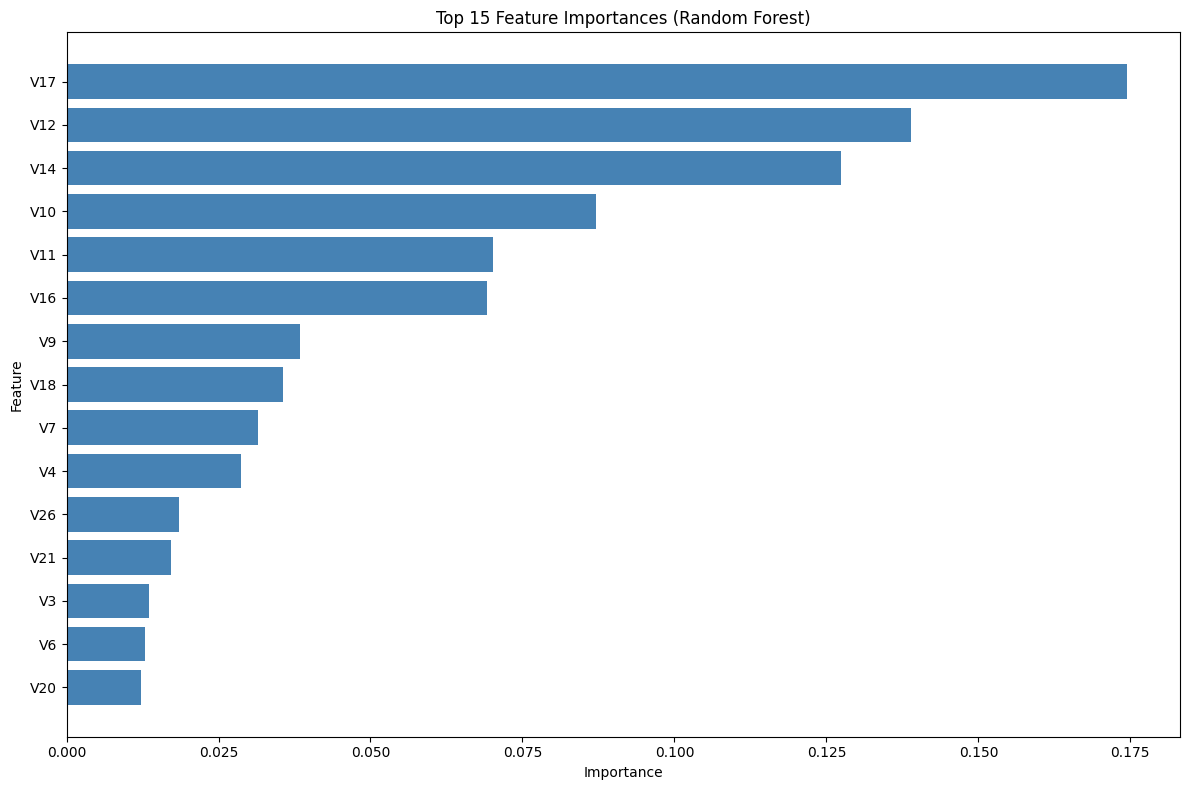

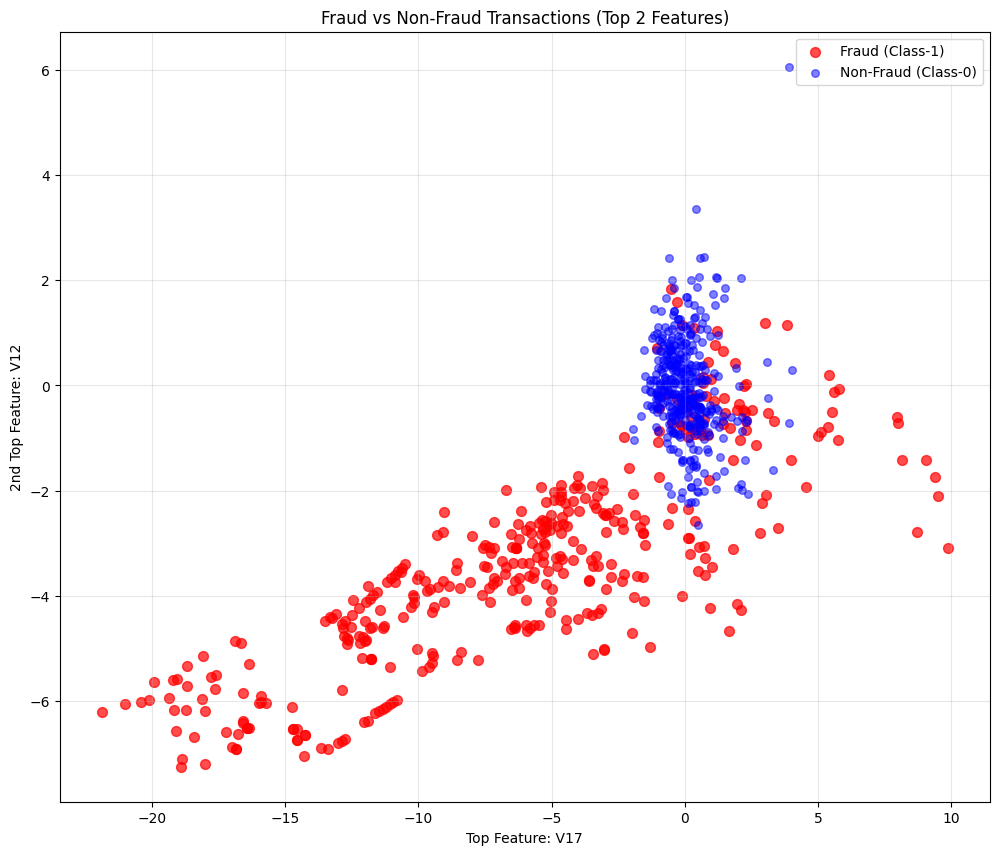

In [23]:
# Feature Importance Analysis for Random Forest
var_imp = []
for i in clf.feature_importances_:
    var_imp.append(i)

print("Feature Importance Analysis:")

print('Top var =', var_imp.index(np.sort(clf.feature_importances_)[-1])+1)
print('2nd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-2])+1)
print('3rd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-3])+1)

# Get feature names and importance values
feature_names = X_train_transformed.columns.tolist()
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': clf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(12, 8))
plt.barh(importance_df['Feature'][:15], importance_df['Importance'][:15], color='steelblue')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Scatter plot of top 2 features
top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-1])
second_top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-2])

X_train_1 = X_train_transformed.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train_transformed.to_numpy()[np.where(y_train==0.0)]

np.random.shuffle(X_train_0)

plt.rcParams['figure.figsize'] = [12, 10]
plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], 
            label='Fraud (Class-1)', alpha=0.7, s=50, color='red')
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Non-Fraud (Class-0)', alpha=0.5, s=30, color='blue')
plt.xlabel(f'Top Feature: {feature_names[top_var_index]}')
plt.ylabel(f'2nd Top Feature: {feature_names[second_top_var_index]}')
plt.title('Fraud vs Non-Fraud Transactions (Top 2 Features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Model building with balancing Classes

##### Perform class balancing with :
- Random Oversampling
- SMOTE
- ADASYN

## Model Building
- Build different models on the balanced dataset and see the result

In [24]:
# Logistic Regression
from sklearn import linear_model #import the package

num_C = [0.001, 0.01, 0.1, 1, 10, 100]  #--> list of values for C parameter
cv_num = 5   #--> number of cross-validation folds

print("Logistic Regression Setup for Balanced Data:")
print(f"C values to test: {num_C}")
print(f"Cross-validation folds: {cv_num}")

Logistic Regression Setup for Balanced Data:
C values to test: [0.001, 0.01, 0.1, 1, 10, 100]
Cross-validation folds: 5


#### perfom cross validation on the X_train & y_train to create:
- X_train_cv
- X_test_cv 
- y_train_cv
- y_test_cv 

### Random Oversampling

In [25]:
from imblearn.over_sampling import RandomOverSampler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score

# Apply Random Oversampling to balance classes
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train_transformed, y_train)

print("Class distribution after Random Oversampling:")
print(y_train_ros.value_counts())

# Hyperparameter tuning with Logistic Regression
param_grid = {'C': num_C}
log_reg_ros = LogisticRegression(max_iter=1000, random_state=42)

log_reg_ros_grid = GridSearchCV(log_reg_ros, param_grid, cv=cv_num, scoring='roc_auc', n_jobs=-1)
log_reg_ros_grid.fit(X_train_ros, y_train_ros)

# Evaluation results
y_pred_ros = log_reg_ros_grid.predict_proba(X_test_transformed)[:, 1]
ros_test_auc = roc_auc_score(y_test, y_pred_ros)

print("Logistic Regression on Random Oversampling:")
print(f"\nBest CV AUC Score: {log_reg_ros_grid.best_score_:.4f}")
print(f"Test AUC Score: {ros_test_auc:.4f}")
print(f"Best C value: {log_reg_ros_grid.best_params_['C']}")

Class distribution after Random Oversampling:
Class
0    227451
1    227451
Name: count, dtype: int64
Logistic Regression on Random Oversampling:

Best CV AUC Score: 0.9886
Test AUC Score: 0.9731
Best C value: 100


### Similarly explore other algorithms on balanced dataset by building models like:
- KNN
- SVM
- Decision Tree
- Random Forest
- XGBoost

In [26]:
# KNN on Random Oversampling balanced data
from sklearn.neighbors import KNeighborsClassifier

knn_ros = KNeighborsClassifier()
knn_ros_params = {'n_neighbors': [3, 5, 7, 9]}

knn_ros_grid = GridSearchCV(knn_ros, knn_ros_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
knn_ros_grid.fit(X_train_ros, y_train_ros)

y_pred_knn_ros = knn_ros_grid.predict_proba(X_test_transformed)[:, 1]
knn_ros_test_auc = roc_auc_score(y_test, y_pred_knn_ros)

print("KNN on Random Oversampling:")
print(f"Best CV AUC Score: {knn_ros_grid.best_score_:.4f}")
print(f"Test AUC Score: {knn_ros_test_auc:.4f}")
print(f"Best Parameters: {knn_ros_grid.best_params_}")

KNN on Random Oversampling:
Best CV AUC Score: 0.9999
Test AUC Score: 0.9386
Best Parameters: {'n_neighbors': 3}


In [27]:
# SVM on Random Oversampling balanced data
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

svm_ros = LinearSVC(max_iter=10000, random_state=42)
svm_ros_params = {'C': [0.01, 0.1, 1, 10]}

svm_ros_grid = GridSearchCV(svm_ros, svm_ros_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
svm_ros_grid.fit(X_train_ros, y_train_ros)

# Calibrate for probability predictions
svm_ros_calibrated = CalibratedClassifierCV(svm_ros_grid.best_estimator_, cv=3)
svm_ros_calibrated.fit(X_train_ros, y_train_ros)

y_pred_svm_ros = svm_ros_calibrated.predict_proba(X_test_transformed)[:, 1]
svm_ros_test_auc = roc_auc_score(y_test, y_pred_svm_ros)

print("SVM on Random Oversampling:")
print(f"Best CV AUC Score: {svm_ros_grid.best_score_:.4f}")
print(f"Test AUC Score: {svm_ros_test_auc:.4f}")
print(f"Best Parameters: {svm_ros_grid.best_params_}")

SVM on Random Oversampling:
Best CV AUC Score: 0.9879
Test AUC Score: 0.9758
Best Parameters: {'C': 10}


In [28]:
# Decision Tree on Random Oversampling balanced data
from sklearn.tree import DecisionTreeClassifier

dt_ros = DecisionTreeClassifier(random_state=42)
dt_ros_params = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}

dt_ros_grid = GridSearchCV(dt_ros, dt_ros_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
dt_ros_grid.fit(X_train_ros, y_train_ros)

y_pred_dt_ros = dt_ros_grid.predict_proba(X_test_transformed)[:, 1]
dt_ros_test_auc = roc_auc_score(y_test, y_pred_dt_ros)

print("Decision Tree on Random Oversampling:")
print(f"Best CV AUC Score: {dt_ros_grid.best_score_:.4f}")
print(f"Test AUC Score: {dt_ros_test_auc:.4f}")
print(f"Best Parameters: {dt_ros_grid.best_params_}")

Decision Tree on Random Oversampling:
Best CV AUC Score: 0.9992
Test AUC Score: 0.9017
Best Parameters: {'max_depth': 10, 'min_samples_split': 2}


In [29]:
# Random Forest on Random Oversampling balanced data
from sklearn.ensemble import RandomForestClassifier

rf_ros = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_ros_params = {'n_estimators': [50, 100], 'max_depth': [5, 10, 15]}

rf_ros_grid = GridSearchCV(rf_ros, rf_ros_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
rf_ros_grid.fit(X_train_ros, y_train_ros)

y_pred_rf_ros = rf_ros_grid.predict_proba(X_test_transformed)[:, 1]
rf_ros_test_auc = roc_auc_score(y_test, y_pred_rf_ros)

print("Random Forest on Random Oversampling:")
print(f"Best CV AUC Score: {rf_ros_grid.best_score_:.4f}")
print(f"Test AUC Score: {rf_ros_test_auc:.4f}")
print(f"Best Parameters: {rf_ros_grid.best_params_}")

Random Forest on Random Oversampling:
Best CV AUC Score: 1.0000
Test AUC Score: 0.9551
Best Parameters: {'max_depth': 15, 'n_estimators': 100}


In [30]:
# XGBoost on Random Oversampling balanced data
from xgboost import XGBClassifier

xgb_ros = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
xgb_ros_params = {'n_estimators': [50, 100], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}

xgb_ros_grid = GridSearchCV(xgb_ros, xgb_ros_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
xgb_ros_grid.fit(X_train_ros, y_train_ros)

y_pred_xgb_ros = xgb_ros_grid.predict_proba(X_test_transformed)[:, 1]
xgb_ros_test_auc = roc_auc_score(y_test, y_pred_xgb_ros)

print("XGBoost on Random Oversampling:")
print(f"Best CV AUC Score: {xgb_ros_grid.best_score_:.4f}")
print(f"Test AUC Score: {xgb_ros_test_auc:.4f}")
print(f"Best Parameters: {xgb_ros_grid.best_params_}")

d:\dhondi_a\MS-AIML\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [11:39:16] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost on Random Oversampling:
Best CV AUC Score: 1.0000
Test AUC Score: 0.9752
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}


### Print the class distribution after applying SMOTE 

Class distribution after applying SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64

Original training set size: 227845
After SMOTE training set size: 454902


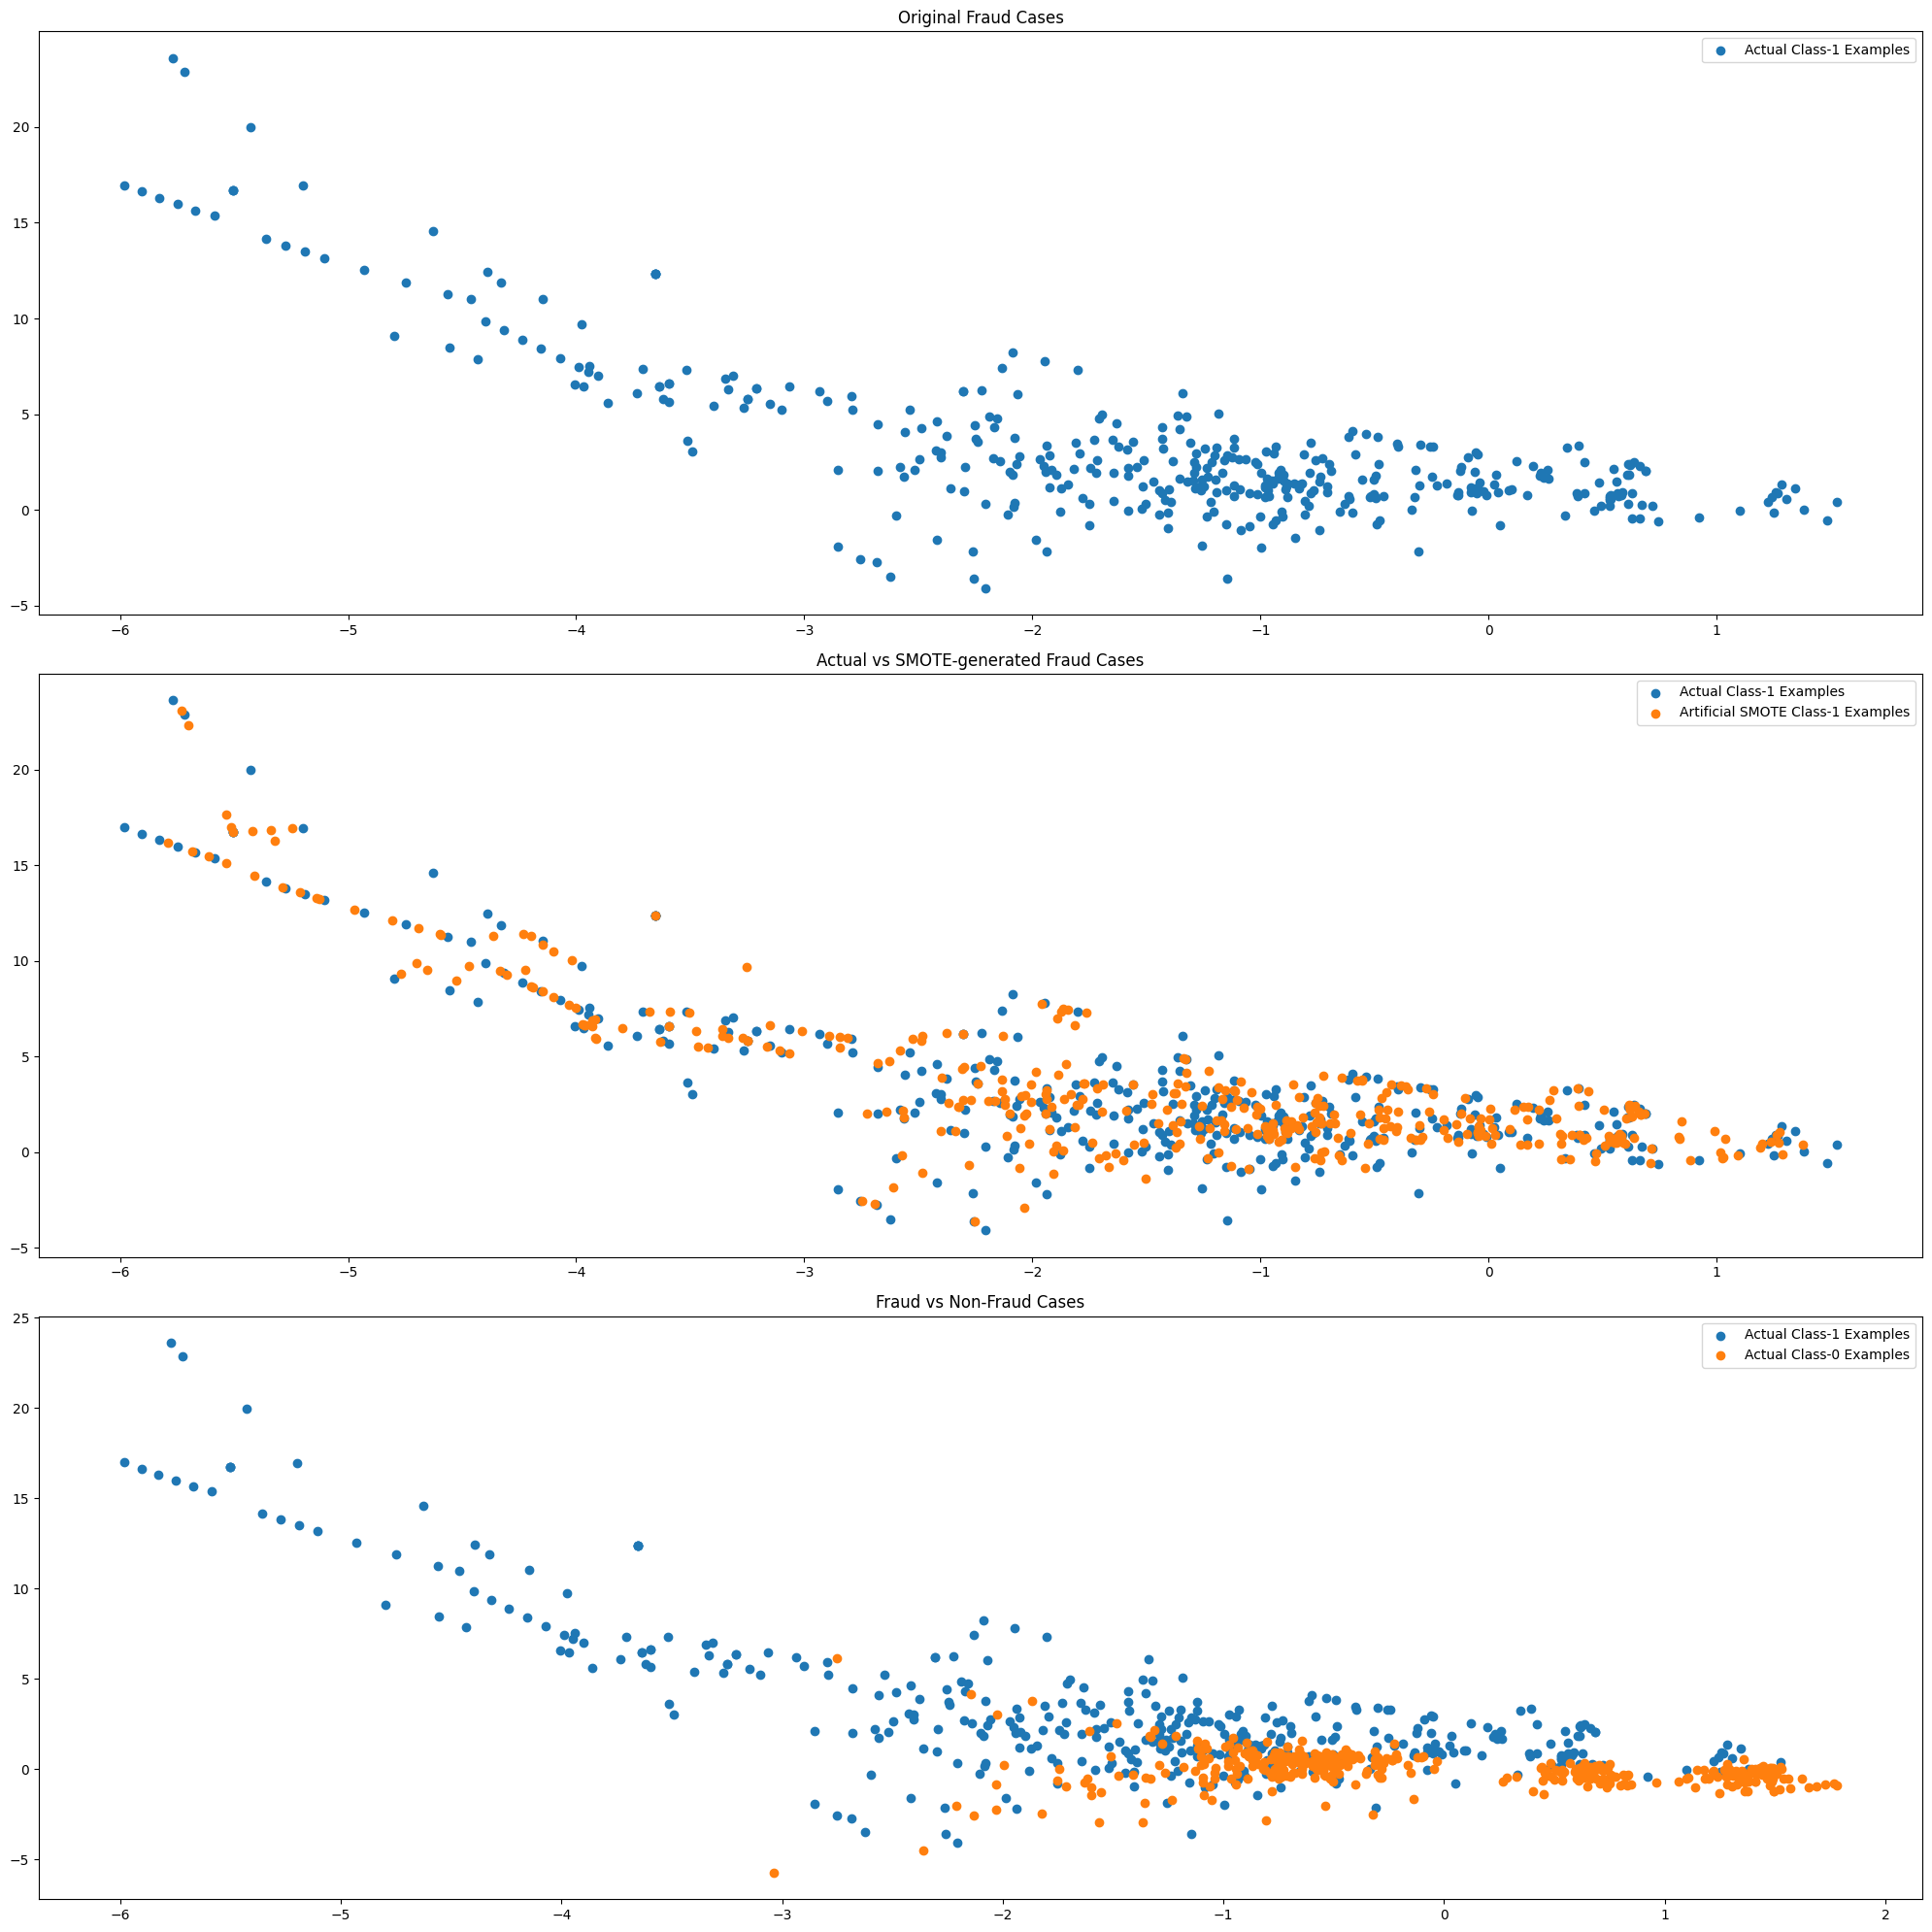

In [31]:
import warnings
warnings.filterwarnings("ignore")

from imblearn import over_sampling

sm = over_sampling.SMOTE(random_state=0)
X_train_smote, y_train_smote = sm.fit_resample(X_train_transformed, y_train)

# Print class distribution after SMOTE
print("Class distribution after applying SMOTE:")
print(y_train_smote.value_counts())
print(f"\nOriginal training set size: {len(y_train)}")
print(f"After SMOTE training set size: {len(y_train_smote)}")

# Artificial minority samples and corresponding minority labels from SMOTE are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from SMOTE, we do
X_train_smote_1 = X_train_smote.iloc[X_train_transformed.shape[0]:]

X_train_1 = X_train_transformed.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train_transformed.to_numpy()[np.where(y_train==0.0)]

plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()
plt.title('Original Fraud Cases')

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_smote_1.iloc[:X_train_1.shape[0], 0], X_train_smote_1.iloc[:X_train_1.shape[0], 1],
            label='Artificial SMOTE Class-1 Examples')
plt.legend()
plt.title('Actual vs SMOTE-generated Fraud Cases')

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()
plt.title('Fraud vs Non-Fraud Cases')

plt.tight_layout()

In [32]:
# Logistic Regression on SMOTE balanced data

#perform hyperparameter tuning
log_reg_smote = LogisticRegression(max_iter=1000, random_state=42)
log_reg_smote_grid = GridSearchCV(log_reg_smote, {'C': num_C}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
log_reg_smote_grid.fit(X_train_smote, y_train_smote)

#print the evaluation result by choosing a evaluation metric
y_pred_lr_smote = log_reg_smote_grid.predict_proba(X_test_transformed)[:, 1]
lr_smote_test_auc = roc_auc_score(y_test, y_pred_lr_smote)

print("Logistic Regression on SMOTE:")
print(f"Best CV AUC Score: {log_reg_smote_grid.best_score_:.4f}")
print(f"Test AUC Score: {lr_smote_test_auc:.4f}")

#print the optimum value of hyperparameters
print(f"Best Parameters: {log_reg_smote_grid.best_params_}")

Logistic Regression on SMOTE:
Best CV AUC Score: 0.9908
Test AUC Score: 0.9718
Best Parameters: {'C': 100}


##### Build models on other algorithms to see the better performing on SMOTE

In [33]:
# KNN on SMOTE balanced data
knn_smote = KNeighborsClassifier()
knn_smote_grid = GridSearchCV(knn_smote, {'n_neighbors': [3, 5, 7, 9]}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
knn_smote_grid.fit(X_train_smote, y_train_smote)

y_pred_knn_smote = knn_smote_grid.predict_proba(X_test_transformed)[:, 1]
knn_smote_test_auc = roc_auc_score(y_test, y_pred_knn_smote)

print("KNN on SMOTE:")
print(f"Best CV AUC Score: {knn_smote_grid.best_score_:.4f}")
print(f"Test AUC Score: {knn_smote_test_auc:.4f}")
print(f"Best Parameters: {knn_smote_grid.best_params_}")

KNN on SMOTE:
Best CV AUC Score: 0.9997
Test AUC Score: 0.9484
Best Parameters: {'n_neighbors': 9}


In [34]:
# SVM on SMOTE balanced data
svm_smote = LinearSVC(max_iter=10000, random_state=42)
svm_smote_grid = GridSearchCV(svm_smote, {'C': [0.01, 0.1, 1, 10]}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
svm_smote_grid.fit(X_train_smote, y_train_smote)

svm_smote_calibrated = CalibratedClassifierCV(svm_smote_grid.best_estimator_, cv=3)
svm_smote_calibrated.fit(X_train_smote, y_train_smote)

y_pred_svm_smote = svm_smote_calibrated.predict_proba(X_test_transformed)[:, 1]
svm_smote_test_auc = roc_auc_score(y_test, y_pred_svm_smote)

print("SVM on SMOTE:")
print(f"Best CV AUC Score: {svm_smote_grid.best_score_:.4f}")
print(f"Test AUC Score: {svm_smote_test_auc:.4f}")
print(f"Best Parameters: {svm_smote_grid.best_params_}")

SVM on SMOTE:
Best CV AUC Score: 0.9902
Test AUC Score: 0.9756
Best Parameters: {'C': 10}


In [35]:
# Decision Tree on SMOTE balanced data
dt_smote = DecisionTreeClassifier(random_state=42)
dt_smote_grid = GridSearchCV(dt_smote, {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
dt_smote_grid.fit(X_train_smote, y_train_smote)

y_pred_dt_smote = dt_smote_grid.predict_proba(X_test_transformed)[:, 1]
dt_smote_test_auc = roc_auc_score(y_test, y_pred_dt_smote)

print("Decision Tree on SMOTE:")
print(f"Best CV AUC Score: {dt_smote_grid.best_score_:.4f}")
print(f"Test AUC Score: {dt_smote_test_auc:.4f}")
print(f"Best Parameters: {dt_smote_grid.best_params_}")

Decision Tree on SMOTE:
Best CV AUC Score: 0.9978
Test AUC Score: 0.9173
Best Parameters: {'max_depth': 10, 'min_samples_split': 2}


In [36]:
# Random Forest on SMOTE balanced data
rf_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_smote_grid = GridSearchCV(rf_smote, {'n_estimators': [50, 100], 'max_depth': [5, 10, 15]}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
rf_smote_grid.fit(X_train_smote, y_train_smote)

y_pred_rf_smote = rf_smote_grid.predict_proba(X_test_transformed)[:, 1]
rf_smote_test_auc = roc_auc_score(y_test, y_pred_rf_smote)

print("Random Forest on SMOTE:")
print(f"Best CV AUC Score: {rf_smote_grid.best_score_:.4f}")
print(f"Test AUC Score: {rf_smote_test_auc:.4f}")
print(f"Best Parameters: {rf_smote_grid.best_params_}")

Random Forest on SMOTE:
Best CV AUC Score: 1.0000
Test AUC Score: 0.9818
Best Parameters: {'max_depth': 15, 'n_estimators': 100}


In [37]:
# XGBoost on SMOTE balanced data
xgb_smote = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
xgb_smote_grid = GridSearchCV(xgb_smote, {'n_estimators': [50, 100], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
xgb_smote_grid.fit(X_train_smote, y_train_smote)

y_pred_xgb_smote = xgb_smote_grid.predict_proba(X_test_transformed)[:, 1]
xgb_smote_test_auc = roc_auc_score(y_test, y_pred_xgb_smote)

print("XGBoost on SMOTE:")
print(f"Best CV AUC Score: {xgb_smote_grid.best_score_:.4f}")
print(f"Test AUC Score: {xgb_smote_test_auc:.4f}")
print(f"Best Parameters: {xgb_smote_grid.best_params_}")

XGBoost on SMOTE:
Best CV AUC Score: 1.0000
Test AUC Score: 0.9794
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100}


### Print the class distribution after applying ADASYN

Class distribution after applying ADASYN:
Class
1    227459
0    227451
Name: count, dtype: int64

Original training set size: 227845
After ADASYN training set size: 454910


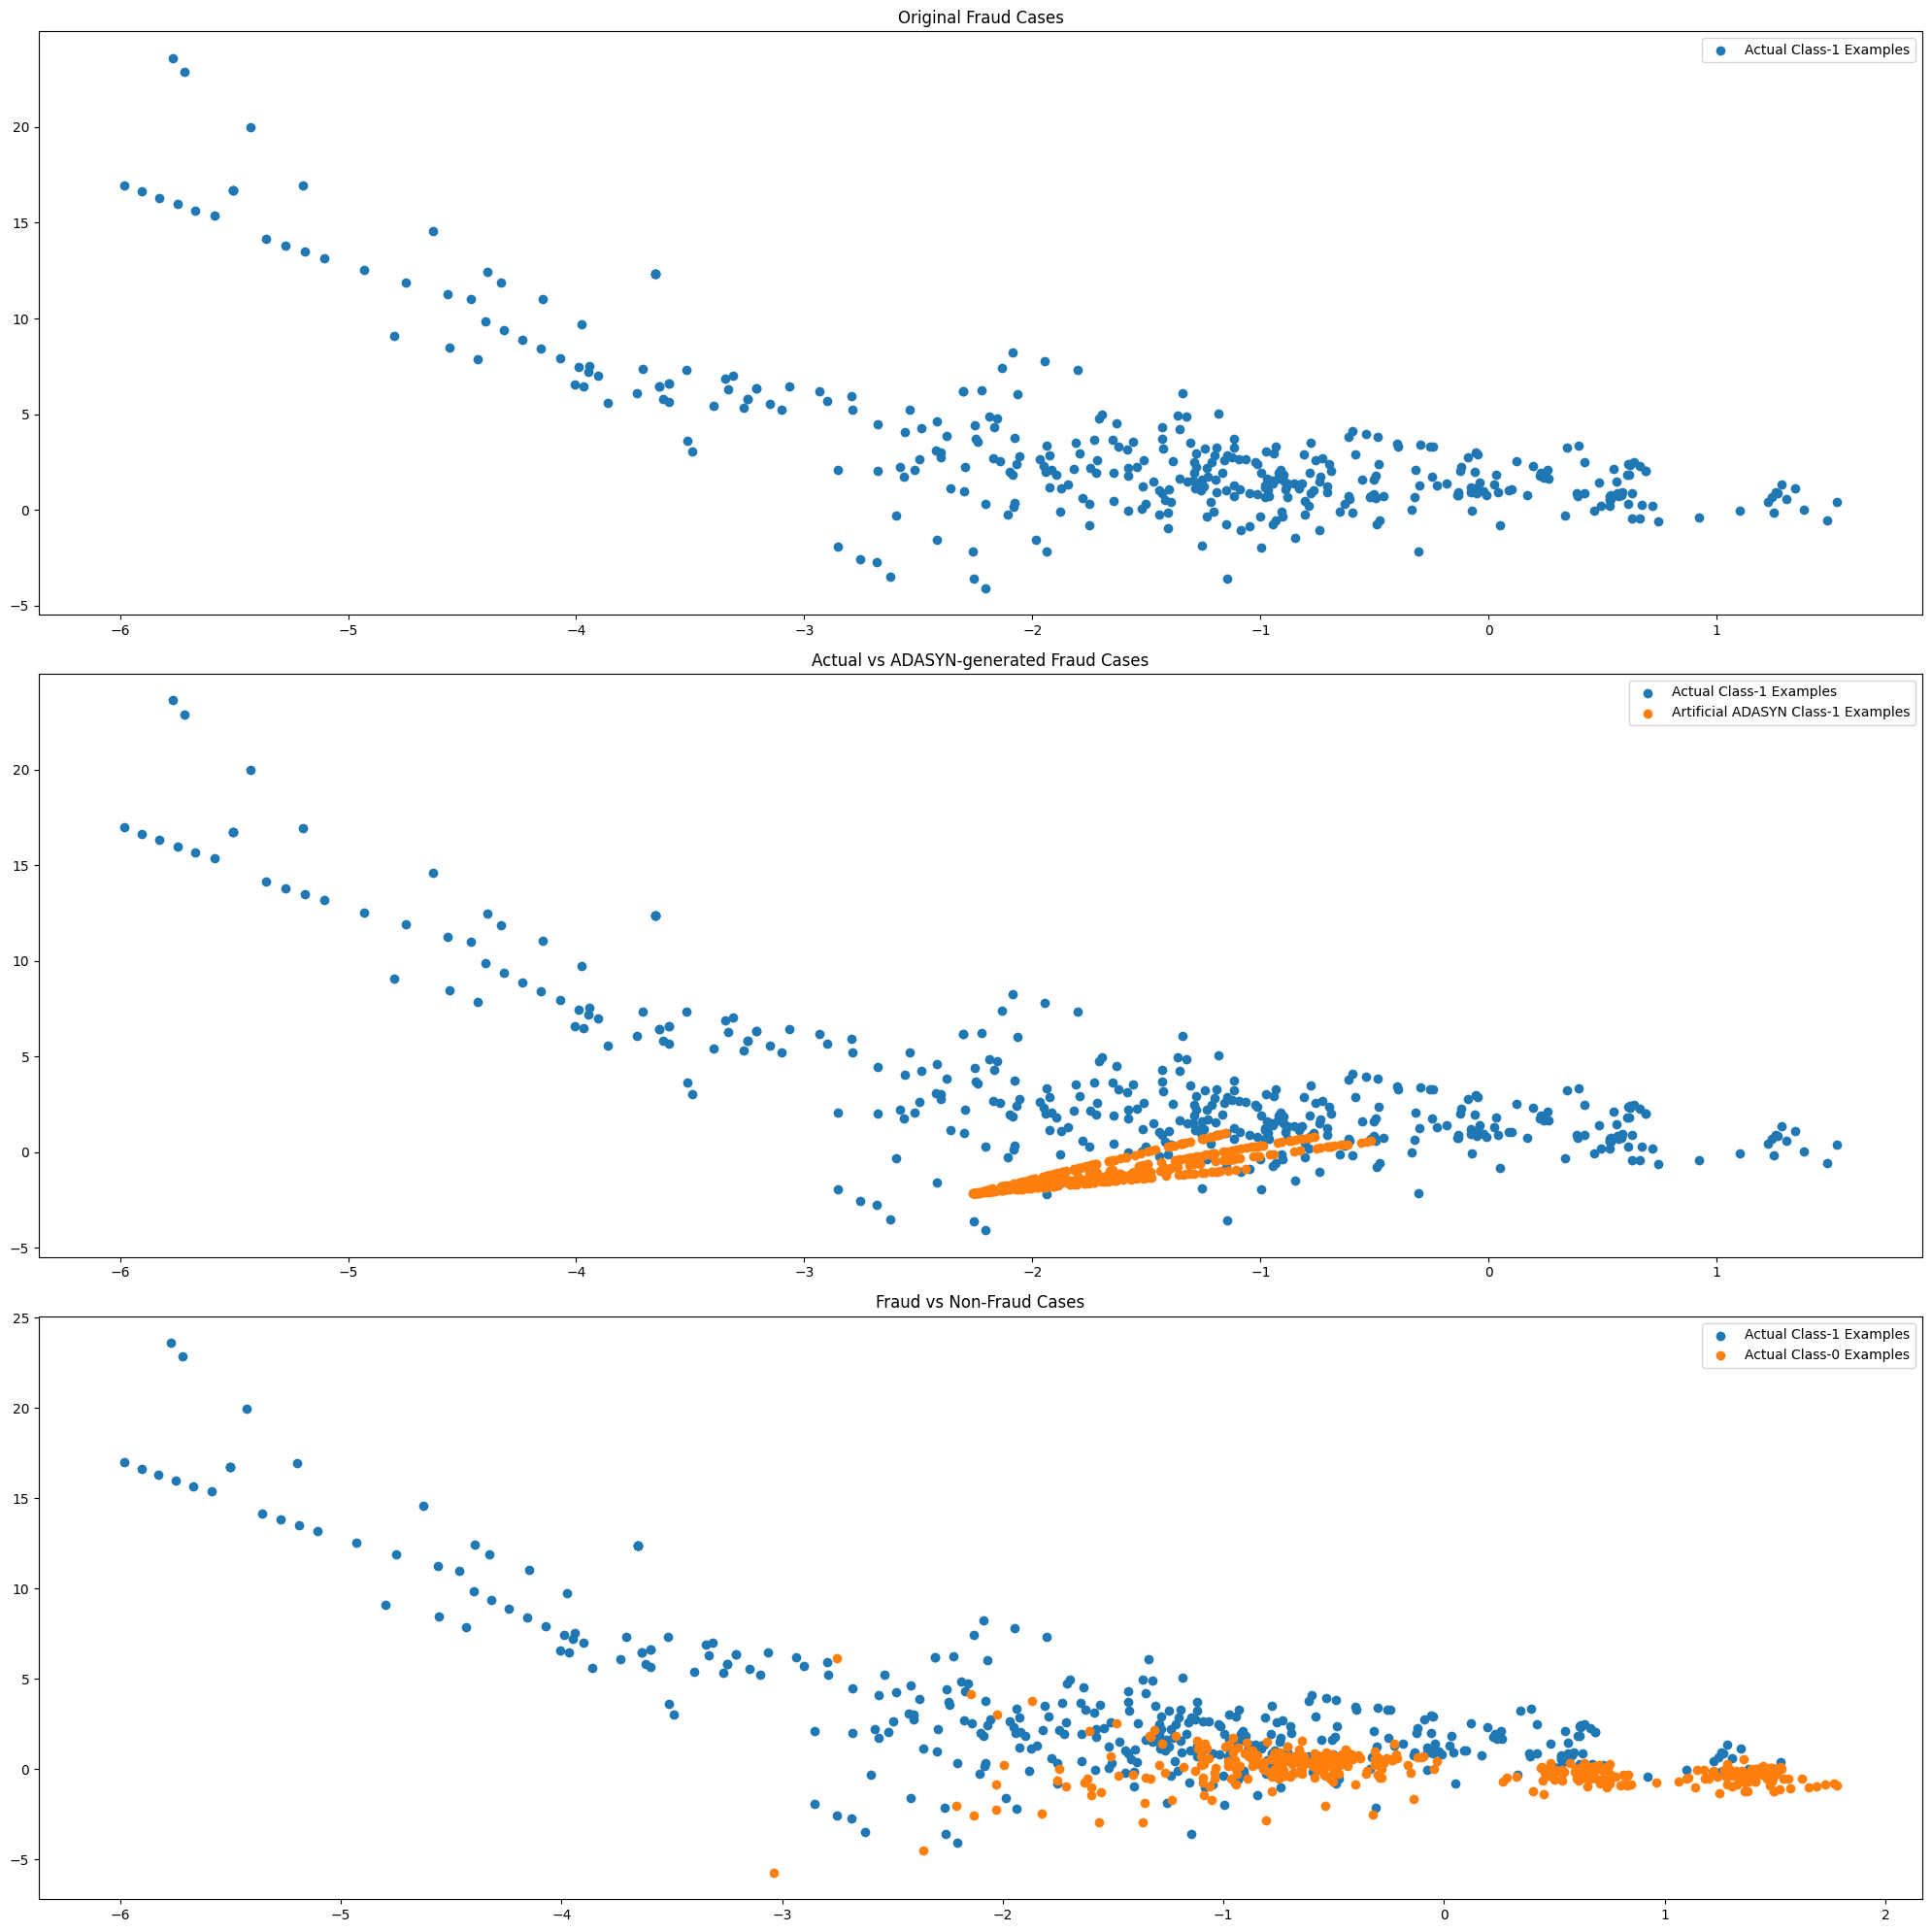

In [38]:
import warnings
warnings.filterwarnings("ignore")

from imblearn import over_sampling

ada = over_sampling.ADASYN(random_state=0)
X_train_adasyn, y_train_adasyn = ada.fit_resample(X_train_transformed, y_train)

# Print class distribution after ADASYN
print("Class distribution after applying ADASYN:")
print(y_train_adasyn.value_counts())
print(f"\nOriginal training set size: {len(y_train)}")
print(f"After ADASYN training set size: {len(y_train_adasyn)}")

# Artificial minority samples and corresponding minority labels from ADASYN are appended
# below X_train and y_train respectively
# So to exclusively get the artificial minority samples from ADASYN, we do
X_train_adasyn_1 = X_train_adasyn.iloc[X_train_transformed.shape[0]:]

X_train_1 = X_train_transformed.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train_transformed.to_numpy()[np.where(y_train==0.0)]

plt.rcParams['figure.figsize'] = [20, 20]
fig = plt.figure()

plt.subplot(3, 1, 1)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.legend()
plt.title('Original Fraud Cases')

plt.subplot(3, 1, 2)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_adasyn_1.iloc[:X_train_1.shape[0], 0], X_train_adasyn_1.iloc[:X_train_1.shape[0], 1],
            label='Artificial ADASYN Class-1 Examples')
plt.legend()
plt.title('Actual vs ADASYN-generated Fraud Cases')

plt.subplot(3, 1, 3)
plt.scatter(X_train_1[:, 0], X_train_1[:, 1], label='Actual Class-1 Examples')
plt.scatter(X_train_0[:X_train_1.shape[0], 0], X_train_0[:X_train_1.shape[0], 1], label='Actual Class-0 Examples')
plt.legend()
plt.title('Fraud vs Non-Fraud Cases')

plt.tight_layout()

In [39]:
# Logistic Regression on ADASYN balanced data

#perform hyperparameter tuning
log_reg_adasyn = LogisticRegression(max_iter=1000, random_state=42)
log_reg_adasyn_grid = GridSearchCV(log_reg_adasyn, {'C': num_C}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
log_reg_adasyn_grid.fit(X_train_adasyn, y_train_adasyn)

#print the evaluation result by choosing a evaluation metric
y_pred_lr_adasyn = log_reg_adasyn_grid.predict_proba(X_test_transformed)[:, 1]
lr_adasyn_test_auc = roc_auc_score(y_test, y_pred_lr_adasyn)

print("Logistic Regression on ADASYN:")
print(f"Best CV AUC Score: {log_reg_adasyn_grid.best_score_:.4f}")
print(f"Test AUC Score: {lr_adasyn_test_auc:.4f}")

#print the optimum value of hyperparameters
print(f"Best Parameters: {log_reg_adasyn_grid.best_params_}")

Logistic Regression on ADASYN:
Best CV AUC Score: 0.9554
Test AUC Score: 0.9731
Best Parameters: {'C': 0.01}


##### Build models on other algorithms to see the better performing on ADASYN

In [40]:
# KNN on ADASYN balanced data
knn_adasyn = KNeighborsClassifier()
knn_adasyn_grid = GridSearchCV(knn_adasyn, {'n_neighbors': [3, 5, 7, 9]}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
knn_adasyn_grid.fit(X_train_adasyn, y_train_adasyn)

y_pred_knn_adasyn = knn_adasyn_grid.predict_proba(X_test_transformed)[:, 1]
knn_adasyn_test_auc = roc_auc_score(y_test, y_pred_knn_adasyn)

print("KNN on ADASYN:")
print(f"Best CV AUC Score: {knn_adasyn_grid.best_score_:.4f}")
print(f"Test AUC Score: {knn_adasyn_test_auc:.4f}")
print(f"Best Parameters: {knn_adasyn_grid.best_params_}")

KNN on ADASYN:
Best CV AUC Score: 0.9870
Test AUC Score: 0.9484
Best Parameters: {'n_neighbors': 9}


In [41]:
# SVM (LinearSVC) on ADASYN balanced data
from sklearn.calibration import CalibratedClassifierCV

svm_adasyn = LinearSVC(max_iter=10000, dual=False)
svm_adasyn_grid = GridSearchCV(svm_adasyn, {'C': num_C}, cv=cv_num, scoring='roc_auc', n_jobs=-1)
svm_adasyn_grid.fit(X_train_adasyn, y_train_adasyn)

# Wrap with CalibratedClassifierCV for predict_proba
svm_adasyn_calibrated = CalibratedClassifierCV(svm_adasyn_grid.best_estimator_, cv=3)
svm_adasyn_calibrated.fit(X_train_adasyn, y_train_adasyn)

y_pred_svm_adasyn = svm_adasyn_calibrated.predict_proba(X_test_transformed)[:, 1]
svm_adasyn_test_auc = roc_auc_score(y_test, y_pred_svm_adasyn)

print("SVM (LinearSVC) on ADASYN:")
print(f"Best CV AUC Score: {svm_adasyn_grid.best_score_:.4f}")
print(f"Test AUC Score: {svm_adasyn_test_auc:.4f}")
print(f"Best Parameters: {svm_adasyn_grid.best_params_}")

SVM (LinearSVC) on ADASYN:
Best CV AUC Score: 0.9550
Test AUC Score: 0.9745
Best Parameters: {'C': 0.001}


In [42]:
# Decision Tree on ADASYN balanced data
dt_adasyn = DecisionTreeClassifier(random_state=42)
dt_params = {'max_depth': [3, 5, 7, 10], 'min_samples_split': [2, 5, 10]}
dt_adasyn_grid = GridSearchCV(dt_adasyn, dt_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
dt_adasyn_grid.fit(X_train_adasyn, y_train_adasyn)

y_pred_dt_adasyn = dt_adasyn_grid.predict_proba(X_test_transformed)[:, 1]
dt_adasyn_test_auc = roc_auc_score(y_test, y_pred_dt_adasyn)

print("Decision Tree on ADASYN:")
print(f"Best CV AUC Score: {dt_adasyn_grid.best_score_:.4f}")
print(f"Test AUC Score: {dt_adasyn_test_auc:.4f}")
print(f"Best Parameters: {dt_adasyn_grid.best_params_}")

Decision Tree on ADASYN:
Best CV AUC Score: 0.9271
Test AUC Score: 0.9085
Best Parameters: {'max_depth': 10, 'min_samples_split': 10}


In [43]:
# Random Forest on ADASYN balanced data
rf_adasyn = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10, 15]}
rf_adasyn_grid = GridSearchCV(rf_adasyn, rf_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
rf_adasyn_grid.fit(X_train_adasyn, y_train_adasyn)

y_pred_rf_adasyn = rf_adasyn_grid.predict_proba(X_test_transformed)[:, 1]
rf_adasyn_test_auc = roc_auc_score(y_test, y_pred_rf_adasyn)

print("Random Forest on ADASYN:")
print(f"Best CV AUC Score: {rf_adasyn_grid.best_score_:.4f}")
print(f"Test AUC Score: {rf_adasyn_test_auc:.4f}")
print(f"Best Parameters: {rf_adasyn_grid.best_params_}")

Random Forest on ADASYN:
Best CV AUC Score: 0.9934
Test AUC Score: 0.9777
Best Parameters: {'max_depth': 15, 'n_estimators': 200}


In [44]:
# XGBoost on ADASYN balanced data
xgb_adasyn = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.1]}
xgb_adasyn_grid = GridSearchCV(xgb_adasyn, xgb_params, cv=cv_num, scoring='roc_auc', n_jobs=-1)
xgb_adasyn_grid.fit(X_train_adasyn, y_train_adasyn)

y_pred_xgb_adasyn = xgb_adasyn_grid.predict_proba(X_test_transformed)[:, 1]
xgb_adasyn_test_auc = roc_auc_score(y_test, y_pred_xgb_adasyn)

print("XGBoost on ADASYN:")
print(f"Best CV AUC Score: {xgb_adasyn_grid.best_score_:.4f}")
print(f"Test AUC Score: {xgb_adasyn_test_auc:.4f}")
print(f"Best Parameters: {xgb_adasyn_grid.best_params_}")

XGBoost on ADASYN:
Best CV AUC Score: 0.9971
Test AUC Score: 0.9811
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}


### Select the oversampling method which shows the best result on a model
- Apply the best hyperparameter on the model
- Predict on the test dataset

In [45]:
# MODEL COMPARISON SUMMARY ACROSS ALL OVERSAMPLING TECHNIQUES

print("Comprehensive Model Comparison: All Oversampling Techniques")

# Create comparison DataFrame
comparison_data = {
    'Model': ['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'ROS_Test_AUC': [ros_test_auc, knn_ros_test_auc, svm_ros_test_auc, dt_ros_test_auc, rf_ros_test_auc, xgb_ros_test_auc],
    'SMOTE_Test_AUC': [lr_smote_test_auc, knn_smote_test_auc, svm_smote_test_auc, dt_smote_test_auc, rf_smote_test_auc, xgb_smote_test_auc],
    'ADASYN_Test_AUC': [lr_adasyn_test_auc, knn_adasyn_test_auc, svm_adasyn_test_auc, dt_adasyn_test_auc, rf_adasyn_test_auc, xgb_adasyn_test_auc]
}

comparison_df = pd.DataFrame(comparison_data)
comparison_df['Best_Technique'] = comparison_df[['ROS_Test_AUC', 'SMOTE_Test_AUC', 'ADASYN_Test_AUC']].idxmax(axis=1)
comparison_df['Best_AUC'] = comparison_df[['ROS_Test_AUC', 'SMOTE_Test_AUC', 'ADASYN_Test_AUC']].max(axis=1)

print("\nTest AUC Scores Comparison:")
print("-"*90)
print(comparison_df.to_string(index=False))

# Find overall best combination
best_idx = comparison_df['Best_AUC'].idxmax()
best_model = comparison_df.loc[best_idx, 'Model']
best_technique = comparison_df.loc[best_idx, 'Best_Technique'].replace('_Test_AUC', '')
best_auc = comparison_df.loc[best_idx, 'Best_AUC']

print(f"🏆 Best Combination: {best_model} with {best_technique}")
print(f"   Test AUC Score: {best_auc:.4f}")

Comprehensive Model Comparison: All Oversampling Techniques

Test AUC Scores Comparison:
------------------------------------------------------------------------------------------
              Model  ROS_Test_AUC  SMOTE_Test_AUC  ADASYN_Test_AUC  Best_Technique  Best_AUC
Logistic Regression      0.973145        0.971767         0.973124    ROS_Test_AUC  0.973145
                KNN      0.938648        0.948401         0.948392  SMOTE_Test_AUC  0.948401
                SVM      0.975778        0.975597         0.974511    ROS_Test_AUC  0.975778
      Decision Tree      0.901673        0.917281         0.908525  SMOTE_Test_AUC  0.917281
      Random Forest      0.955112        0.981821         0.977736  SMOTE_Test_AUC  0.981821
            XGBoost      0.975182        0.979424         0.981065 ADASYN_Test_AUC  0.981065
🏆 Best Combination: Random Forest with SMOTE
   Test AUC Score: 0.9818


Final Model Selection: Random Forest with SMOTE Oversampling

Model Parameters:
  - n_estimators: 100
  - max_depth: 15
  - Oversampling: SMOTE

Test Set Evaluation Metrics:
  - AUC-ROC Score: 0.9818
  - Precision: 0.6457
  - Recall: 0.8367
  - F1-Score: 0.7289

Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00     56864
       Fraud       0.65      0.84      0.73        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
[[56819    45]
 [   16    82]]


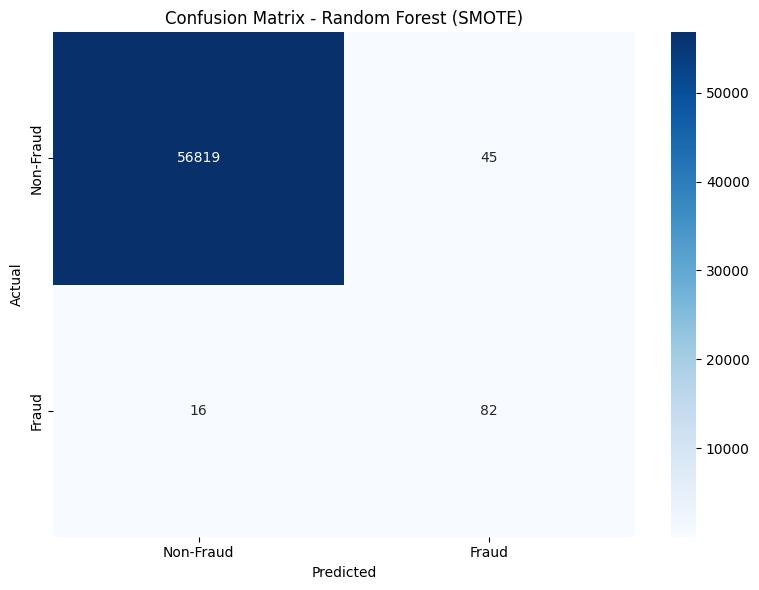


- Best Model Selected: Random Forest with SMOTE
- This model provides the best balance between detecting fraud and minimizing false positives


In [46]:
# BEST MODEL: RANDOM FOREST with SMOTE (Highest Test AUC = 0.9818)

# Observation: Random Forest with SMOTE achieved the highest Test AUC of 0.9818
# Best hyperparameters: max_depth=15, n_estimators=100

print("Final Model Selection: Random Forest with SMOTE Oversampling")

# Initialize the best model with optimum hyperparameters
clf = RandomForestClassifier(
    n_estimators=rf_smote_grid.best_params_['n_estimators'],
    max_depth=rf_smote_grid.best_params_['max_depth'],
    random_state=42,
    n_jobs=-1
)

# Fit on the SMOTE balanced dataset
clf.fit(X_train_smote, y_train_smote)

# Predict on test data
y_pred_final = clf.predict(X_test_transformed)
y_pred_proba_final = clf.predict_proba(X_test_transformed)[:, 1]

# Evaluation metrics
final_auc = roc_auc_score(y_test, y_pred_proba_final)
final_precision = metrics.precision_score(y_test, y_pred_final)
final_recall = metrics.recall_score(y_test, y_pred_final)
final_f1 = metrics.f1_score(y_test, y_pred_final)

print(f"\nModel Parameters:")
print(f"  - n_estimators: {rf_smote_grid.best_params_['n_estimators']}")
print(f"  - max_depth: {rf_smote_grid.best_params_['max_depth']}")
print(f"  - Oversampling: SMOTE")

print(f"\nTest Set Evaluation Metrics:")
print(f"  - AUC-ROC Score: {final_auc:.4f}")
print(f"  - Precision: {final_precision:.4f}")
print(f"  - Recall: {final_recall:.4f}")
print(f"  - F1-Score: {final_f1:.4f}")

print(f"\nClassification Report:")
print(metrics.classification_report(y_test, y_pred_final, target_names=['Non-Fraud', 'Fraud']))

print(f"\nConfusion Matrix:")
cm_final = metrics.confusion_matrix(y_test, y_pred_final)
print(cm_final)

# Visualize confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Fraud', 'Fraud'], 
            yticklabels=['Non-Fraud', 'Fraud'])
plt.title('Confusion Matrix - Random Forest (SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\n- Best Model Selected: Random Forest with SMOTE")
print("- This model provides the best balance between detecting fraud and minimizing false positives")

### Print the important features of the best model to understand the dataset

Feature Importance Analysis of Final Model:
Top var = 10
2nd Top var = 14
3rd Top var = 4

Top Feature: V10 (Importance: 0.1582)
2nd Top Feature: V14 (Importance: 0.1417)


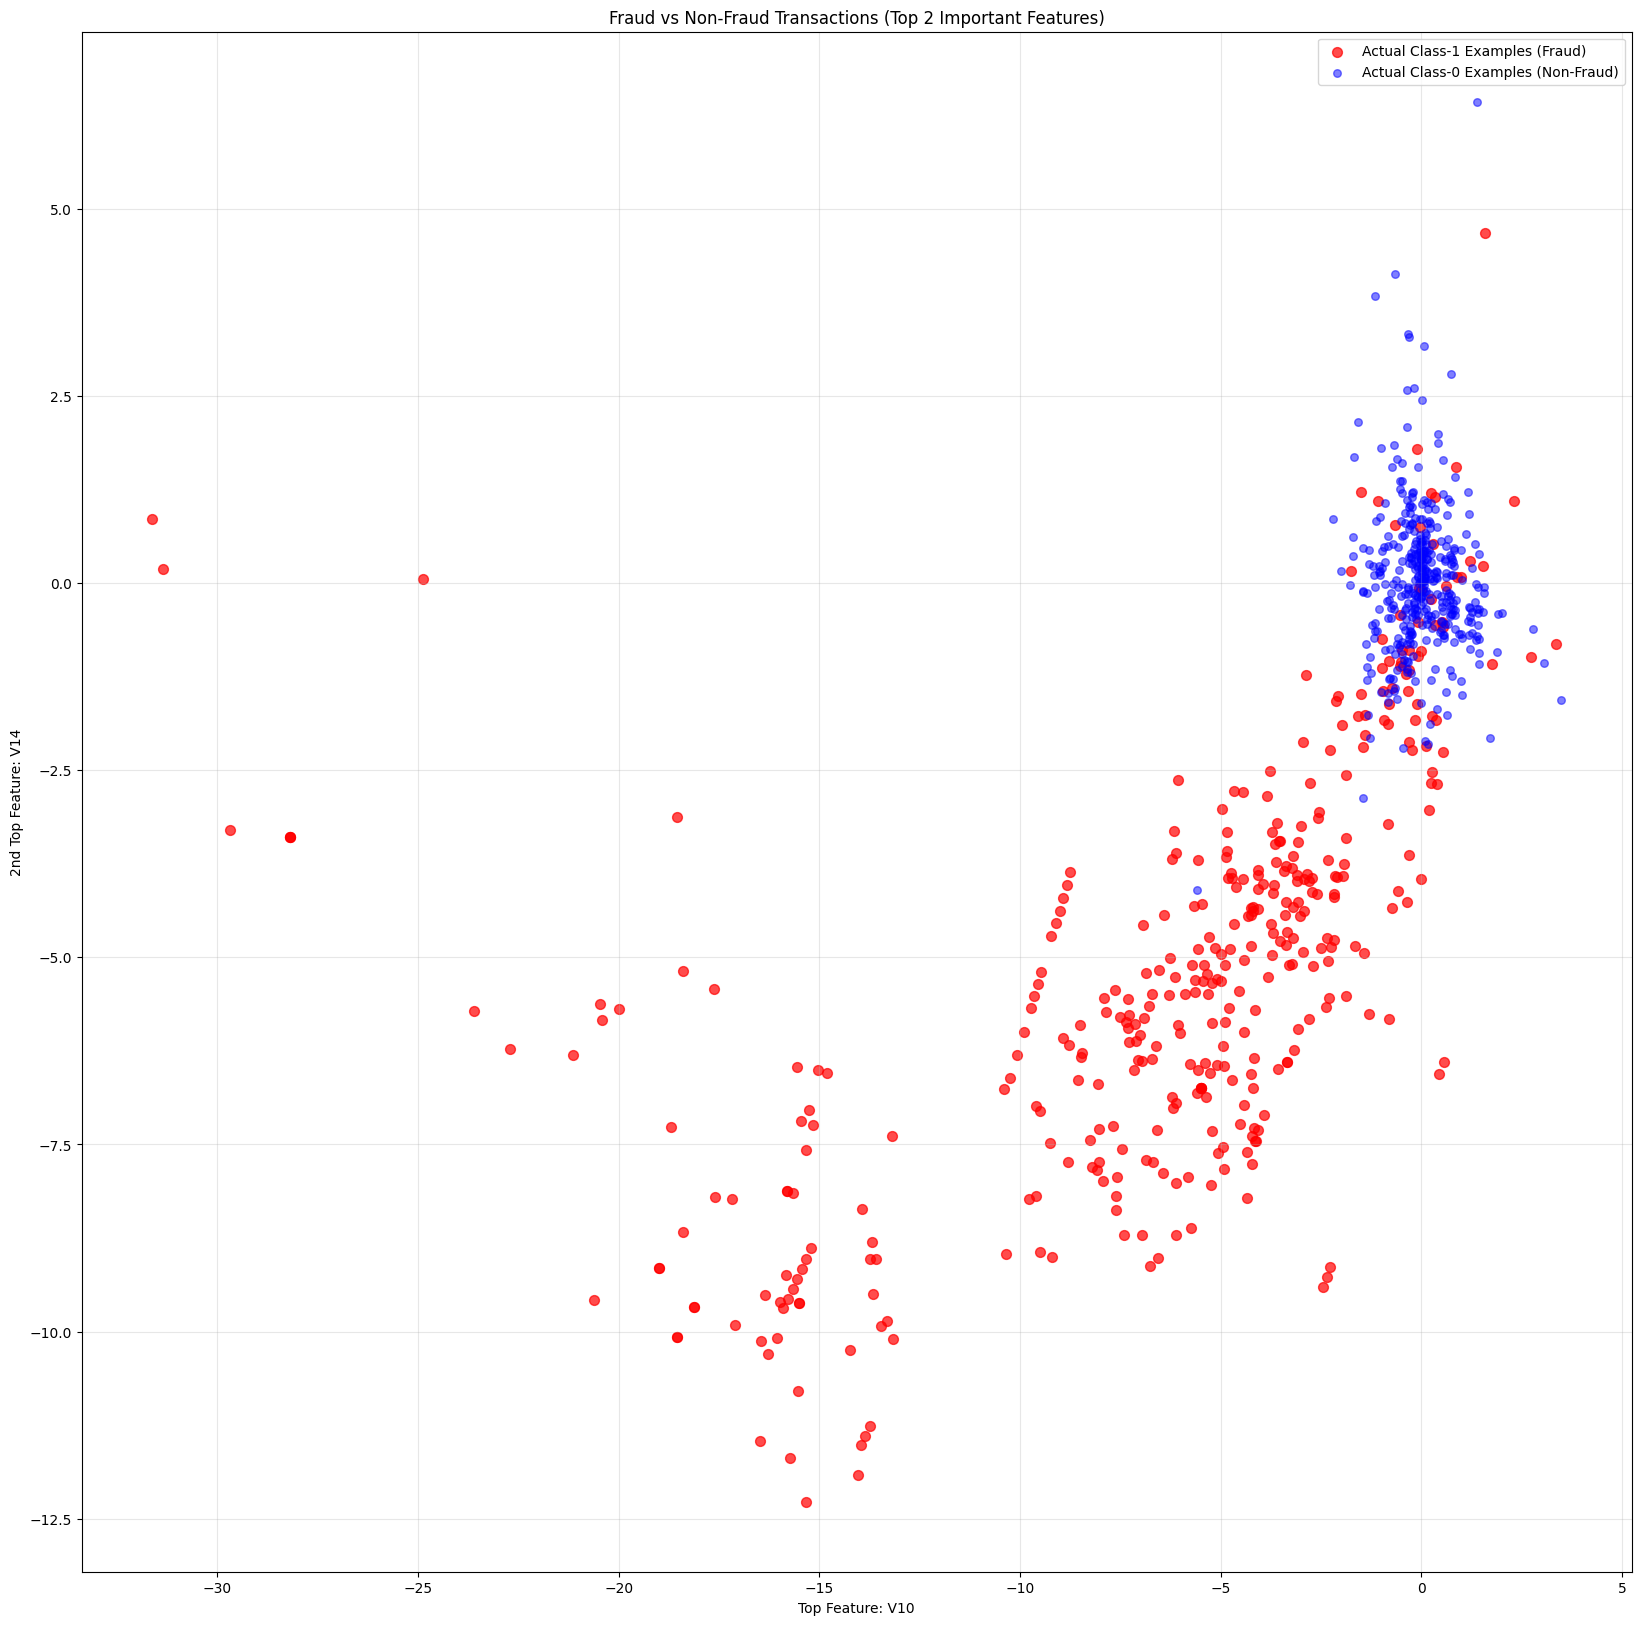

In [47]:
# Print the important features of the best model (Random Forest with SMOTE) to understand the dataset
var_imp = []
for i in clf.feature_importances_:
    var_imp.append(i)

print("Feature Importance Analysis of Final Model:")

print('Top var =', var_imp.index(np.sort(clf.feature_importances_)[-1])+1)
print('2nd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-2])+1)
print('3rd Top var =', var_imp.index(np.sort(clf.feature_importances_)[-3])+1)

# Get feature names for better understanding
feature_names = X_train_transformed.columns.tolist()
top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-1])
second_top_var_index = var_imp.index(np.sort(clf.feature_importances_)[-2])

print(f"\nTop Feature: {feature_names[top_var_index]} (Importance: {clf.feature_importances_[top_var_index]:.4f})")
print(f"2nd Top Feature: {feature_names[second_top_var_index]} (Importance: {clf.feature_importances_[second_top_var_index]:.4f})")

# Variable on Index-13 and Index-9 seems to be the top 2 variables
X_train_1 = X_train_transformed.to_numpy()[np.where(y_train==1.0)]
X_train_0 = X_train_transformed.to_numpy()[np.where(y_train==0.0)]

np.random.shuffle(X_train_0)

import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.figsize'] = [20, 20]

plt.scatter(X_train_1[:, top_var_index], X_train_1[:, second_top_var_index], 
            label='Actual Class-1 Examples (Fraud)', alpha=0.7, s=50, color='red')
plt.scatter(X_train_0[:X_train_1.shape[0], top_var_index], X_train_0[:X_train_1.shape[0], second_top_var_index],
            label='Actual Class-0 Examples (Non-Fraud)', alpha=0.5, s=30, color='blue')
plt.xlabel(f'Top Feature: {feature_names[top_var_index]}')
plt.ylabel(f'2nd Top Feature: {feature_names[second_top_var_index]}')
plt.title('Fraud vs Non-Fraud Transactions (Top 2 Important Features)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Print the FPR,TPR & select the best threshold from the ROC curve

Train AUC = 0.9999977440736053

=== FALSE POSITIVE RATES (FPR) ===
FPR array shape: (4335,)
FPR values: [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 1.75858188e-05
 1.75858188e-05 3.51716376e-05]...
FPR range: [0.0000, 1.0000]

=== TRUE POSITIVE RATES (TPR) ===
TPR array shape: (4335,)
TPR values: [0.         0.01020408 0.19387755 0.2244898  0.40816327 0.42857143
 0.5        0.5        0.67346939 0.67346939]...
TPR range: [0.0000, 1.0000]

=== THRESHOLDS ===
Thresholds array shape: (4335,)
Threshold values: [       inf 0.99992699 0.99986467 0.99985993 0.99976475 0.99975855
 0.98985524 0.98985373 0.94972878 0.94945443]...
Threshold range: [0.0000, inf]

=== OPTIMAL THRESHOLD ANALYSIS ===
Optimal threshold = 0.2310
At optimal threshold:
  - FPR = 0.0041 (0.41%)
  - TPR = 0.9082 (90.82%)
  - Youden's J = 0.9041


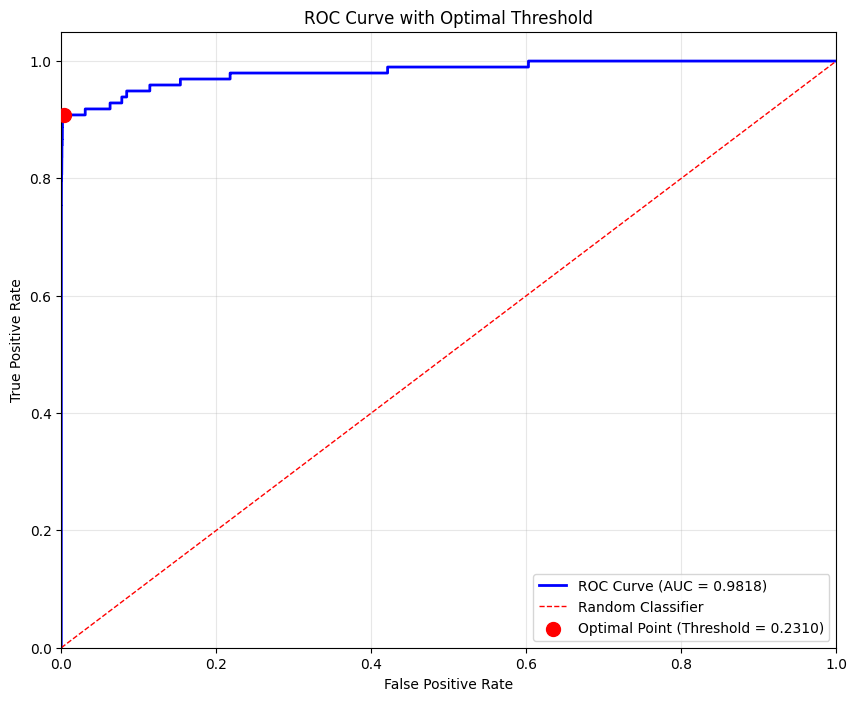

In [48]:
# Calculate ROC curve components
print('Train AUC =', metrics.roc_auc_score(y_train_smote, clf.predict_proba(X_train_smote)[:, 1]))
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba_final)

# Print FPR and TPR arrays
print(f"\n=== FALSE POSITIVE RATES (FPR) ===")
print(f"FPR array shape: {fpr.shape}")
print(f"FPR values: {fpr[:10]}...")  # Show first 10 values
print(f"FPR range: [{fpr.min():.4f}, {fpr.max():.4f}]")

print(f"\n=== TRUE POSITIVE RATES (TPR) ===")
print(f"TPR array shape: {tpr.shape}")
print(f"TPR values: {tpr[:10]}...")  # Show first 10 values
print(f"TPR range: [{tpr.min():.4f}, {tpr.max():.4f}]")

print(f"\n=== THRESHOLDS ===")
print(f"Thresholds array shape: {thresholds.shape}")
print(f"Threshold values: {thresholds[:10]}...")  # Show first 10 values
print(f"Threshold range: [{thresholds.min():.4f}, {thresholds.max():.4f}]")

# Calculate optimal threshold using Youden's J statistic (TPR - FPR)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
optimal_fpr = fpr[optimal_idx]
optimal_tpr = tpr[optimal_idx]

print(f"\n=== OPTIMAL THRESHOLD ANALYSIS ===")
print(f"Optimal threshold = {optimal_threshold:.4f}")
print(f"At optimal threshold:")
print(f"  - FPR = {optimal_fpr:.4f} ({optimal_fpr*100:.2f}%)")
print(f"  - TPR = {optimal_tpr:.4f} ({optimal_tpr*100:.2f}%)")
print(f"  - Youden's J = {tpr[optimal_idx] - fpr[optimal_idx]:.4f}")

# Plot ROC curve with optimal point highlighted
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC Curve (AUC = {metrics.roc_auc_score(y_test, y_pred_proba_final):.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--', label='Random Classifier')
plt.scatter(optimal_fpr, optimal_tpr, color='red', s=100, zorder=3, label=f'Optimal Point (Threshold = {optimal_threshold:.4f})')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve with Optimal Threshold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()